# Bayesian Optimization — Function 4 (4D, Improved)

This notebook runs one step of Bayesian Optimization on a **4-dimensional** black-box function.

### Improvements over the original F4 script

| Area | Original | Improved |
|---|---|---|
| **Seed** | None | `np.random.default_rng(42)` |
| **Data path** | Hardcoded Windows path | `pathlib.Path(".")` — portable |
| **Data loading** | Loads all 8 functions, uses only F4 | Loads F4 only |
| **y transform** | None | None needed (EI score healthy at ~2.78) |
| **Kernel** | RBF | Matérn ν=2.5 |
| **xi** | Fixed at 0.1 | Adaptive (starts at 0.1, decays) |
| **Sampling** | 50k pure random | 50k Sobol quasi-random (tuned for 4D) |
| **L-BFGS-B starts** | 5 | 12 |
| **Acquisition** | EI only | EI or UCB (switchable) |
| **Structure** | One-shot script | Full BO loop with history tracking |
| **Visualization** | None | 2D slice plots (all 6 dimension pairs) + convergence plot |

## 1. Imports & Configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel
from scipy.stats import norm, qmc
from scipy.optimize import minimize

# ── SVM: Classify high vs low regions ────────────────────────────────────────
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# ── Neural Network: MC-Dropout surrogate ─────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
rng  = np.random.default_rng(SEED)
torch.manual_seed(SEED)

## 2. Data Loading

The original script loaded all 8 functions simultaneously but only used F4. Cleaned up to load F4 only.

F4 is **4-dimensional**. The original EI score of `~2.78` is notably high — much larger than F2 (~0.014) or F3 (~0.039). This indicates the GP sees **large potential improvement** in unexplored regions of the 4D space, which makes sense: with the same number of initial observations spread across a higher-dimensional space, coverage is sparser and uncertainty is higher. No log-transform is needed.

In [2]:
# ── Portable data loading ─────────────────────────────────────────────────────
# Place initial_inputs.npy / initial_outputs.npy next to this notebook,
# OR change DATA_DIR to wherever the F4 data lives.
DATA_DIR = Path("C:\\Users\\fakep\\OneDrive\\Bureau\\CAPSTONE\\function_4\\")    # <-- edit if needed

X = np.load(DATA_DIR / "initial_inputs.npy")
y = np.load(DATA_DIR / "initial_outputs.npy")

n_dim = X.shape[1]
print(f"Loaded {len(y)} observations, {n_dim} dimensions.")
print(f"y range : [{y.min():.4f}, {y.max():.4f}]")
print(f"Current best y = {y.max():.6f}  (at index {y.argmax()})")

Loaded 30 observations, 4 dimensions.
y range : [-32.6257, -4.0255]
Current best y = -4.025542  (at index 27)


## 3. Gaussian Process Model

We use a **Matérn ν=2.5 kernel** instead of the original RBF:
- **RBF** assumes infinite differentiability — often an overly smooth assumption
- **Matérn 5/2** assumes only twice differentiability, which generalises better for real-world black-box functions

In 4D the GP must interpolate across a larger volume with the same number of initial points — making the choice of kernel more impactful than in 2D. Matérn's flexibility helps avoid overconfident predictions in unsampled regions.

In [3]:
def build_gp(n_dim: int) -> GaussianProcessRegressor:
    kernel = (
        C(1.0, constant_value_bounds=(1e-3, 1e5))
        * Matern(length_scale=[1.0] * n_dim,
                 length_scale_bounds=(1e-3, 1e3),
                 nu=2.5)
        + WhiteKernel(noise_level=1e-5,
                      noise_level_bounds=(1e-7, 1e-1))
    )
    return GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=25,
        alpha=1e-6,
        normalize_y=True,
    )

## 4. Acquisition Functions

Acquisition functions decide **where to sample next** by balancing exploration (uncertain regions) and exploitation (promising regions).

### Expected Improvement (EI)
$$EI(x) = (\mu(x) - y_{max} - \xi) \cdot \Phi(Z) + \sigma(x) \cdot \phi(Z), \quad Z = \frac{\mu(x) - y_{max} - \xi}{\sigma(x)}$$
where `ξ` (xi) controls the exploration-exploitation trade-off.

### Upper Confidence Bound (UCB)
$$UCB(x) = \mu(x) + \kappa \cdot \sigma(x)$$
where `κ` controls how much uncertainty is rewarded.

### Adaptive xi
The original F4 script had `xi=0.1` — the only one among F1–F4 that wasn't zero. This was a good instinct given the high EI score and 4D space. We preserve that higher starting value (`xi_init=0.1`) and decay it over iterations, so early steps stay exploratory while later steps focus on exploitation.

In [4]:
def expected_improvement(X_cand, gp, y_max, xi=0.01):
    """Expected Improvement — higher is better."""
    X_cand = np.atleast_2d(X_cand)
    mu, sigma = gp.predict(X_cand, return_std=True)
    sigma = np.maximum(sigma, 1e-8)
    imp   = mu - y_max - xi
    Z     = imp / sigma
    ei    = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma <= 1e-8] = 0.0
    return ei


def upper_confidence_bound(X_cand, gp, kappa=2.576):
    """UCB — higher kappa = more exploration."""
    X_cand = np.atleast_2d(X_cand)
    mu, sigma = gp.predict(X_cand, return_std=True)
    return mu + kappa * sigma


def adaptive_xi(iteration: int, xi_init=0.1, decay=0.85) -> float:
    """
    Decay xi over iterations for a smooth exploration -> exploitation shift.
    xi_init=0.1 matches the original F4 value, preserving the exploratory intent.
    """
    return max(xi_init * (decay ** iteration), 1e-4)

## 5. Next-Point Suggestion

We find the next point to evaluate in three steps:

1. **Sobol sampling** — generate `n_sobol` quasi-random candidates in [0,1]⁴. 50,000 Sobol points provide significantly better space coverage than 50,000 pure random points, thanks to the low-discrepancy property of Sobol sequences — they avoid clustering and gaps that random sampling produces.
2. **Score & rank** — evaluate the acquisition function on all candidates and keep the top `n_best`.
3. **Local optimisation** — run L-BFGS-B from each of the top `n_best=12` starting points. More restarts than 3D (10) to account for the more complex 4D acquisition surface, while staying below 8D's 15.

In [5]:
def suggest_next_point(
    gp,
    y_max,
    n_dim,
    xi=0.01,
    n_sobol=50_000,   # tuned for 4D
    n_best=12,        # scaled between 3D (10) and 8D (15)
    acq="ei",
    kappa=2.576,
    seed=None,
):
    # Step 1 — Sobol candidates
    sampler = qmc.Sobol(d=n_dim, scramble=True, seed=seed)
    X_cand  = sampler.random(n_sobol)

    # Step 2 — Score
    if acq == "ucb":
        scores = upper_confidence_bound(X_cand, gp, kappa=kappa)
    else:
        scores = expected_improvement(X_cand, gp, y_max, xi=xi)

    # Step 3 — Local optimisation from top-n_best starts
    starts = X_cand[np.argsort(scores)[-n_best:]]
    bounds = [(0, 1)] * n_dim

    if acq == "ucb":
        obj = lambda x: -upper_confidence_bound(x, gp, kappa=kappa).item()
    else:
        obj = lambda x: -expected_improvement(x, gp, y_max, xi=xi).item()

    best_x, best_score = None, -np.inf
    for x0 in starts:
        res = minimize(obj, x0=x0, bounds=bounds, method="L-BFGS-B")
        if -res.fun > best_score:
            best_score = -res.fun
            best_x     = res.x

    return best_x, best_score

## 6. 4D Slice Visualisation Helper

In 4 dimensions there are **6 possible dimension pairs** (4 choose 2): (x₁,x₂), (x₁,x₃), (x₁,x₄), (x₂,x₃), (x₂,x₄), (x₃,x₄). We render all 6 slices in a 2×3 grid, fixing the two remaining dimensions at `x_next`'s values in each case.

This gives a comprehensive view of the acquisition landscape across every pair of dimensions simultaneously, making it easy to spot where the optimizer is focusing and whether any dimension is being neglected.

As with F3, observed points are projected onto each 2D plane with **opacity proportional to proximity** to the fixed dimension values.

In [6]:
def plot_slices_4d(gp, X_obs, x_next, acq_fn, iteration, acq_label="EI"):
    """
    2x3 grid of acquisition function slice plots covering all 6 dimension pairs.
    Each panel fixes the two non-plotted dimensions at x_next's values.
    """
    resolution = 100   # lower than 3D to keep 6-panel render time reasonable
    grid_1d    = np.linspace(0, 1, resolution)
    G1, G2     = np.meshgrid(grid_1d, grid_1d)
    flat1      = G1.ravel()
    flat2      = G2.ravel()

    dim_labels = ["x1", "x2", "x3", "x4"]
    dim_pairs  = list(combinations(range(4), 2))   # all 6 pairs

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes      = axes.ravel()
    fig.suptitle(
        f"Bayesian Optimization - F4  |  Iteration {iteration}  |  "
        f"Acquisition ({acq_label}) - all dimension pairs",
        fontsize=12
    )

    for ax, (d0, d1) in zip(axes, dim_pairs):
        # Fixed dimensions are those not in (d0, d1)
        fixed_dims = [d for d in range(4) if d not in (d0, d1)]

        # Build grid: sweep d0 and d1, fix others at x_next values
        X_grid        = np.tile(x_next, (resolution * resolution, 1))
        X_grid[:, d0] = flat1
        X_grid[:, d1] = flat2

        acq_vals = acq_fn(X_grid).reshape(resolution, resolution)

        im = ax.contourf(G1, G2, acq_vals, levels=50, cmap="inferno")
        fig.colorbar(im, ax=ax, shrink=0.85)

        # Project observed points; opacity = proximity to both fixed dim values
        dist   = np.mean([np.abs(X_obs[:, fd] - x_next[fd]) for fd in fixed_dims], axis=0)
        alphas = np.clip(1.0 - dist / 0.3, 0.1, 1.0)
        for xi_obs, yi_obs, a in zip(X_obs[:, d0], X_obs[:, d1], alphas):
            ax.scatter(xi_obs, yi_obs, c="white", edgecolors="black",
                       s=30, alpha=float(a), zorder=5)

        # Suggested next point projection
        ax.scatter(x_next[d0], x_next[d1], c="red", marker="*",
                   s=250, zorder=6, label="Next point")

        fix_str = ", ".join(f"{dim_labels[fd]}={x_next[fd]:.2f}" for fd in fixed_dims)
        ax.set_title(f"{dim_labels[d0]}-{dim_labels[d1]}  ({fix_str})")
        ax.set_xlabel(dim_labels[d0])
        ax.set_ylabel(dim_labels[d1])

    axes[-1].legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.savefig(f"bo_f4_iter_{iteration:03d}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7. Bayesian Optimization Loop

The full BO loop follows this cycle each iteration:

```
Fit GP  ->  Compute xi  ->  Maximise acquisition  ->  Suggest x_next
         ^                                                  |
         +---- Append (x_next, y_new) to dataset  <--------+
                   (you evaluate y_new externally)
```

**To use this loop:**
1. Run the cell — it will print the suggested point and render the 6-panel slice plot
2. Evaluate the real function at `x_next` to get `y_new`
3. Uncomment the three lines under `PLUG YOUR EVALUATOR HERE`
4. Set `N_ITER > 1` and re-run for multi-step optimization

> **Note:** no log-transform is applied. Append the raw `y_new` value directly to `y_obs`.

C:\Users\fakep\AppData\Local\Temp\ipykernel_1648\1024251737.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   1  |  xi = 0.10000  |  acq = EI
  Current best y (log)          : -4.025542
  ✅ Suggested x CAPSTONE       : 0.440403-0.425449-0.378342-0.397112
  🎯 Suggested x                : [0.440403, 0.425449, 0.378342, 0.397112]
  📈 Acq. score                 : 2.141299


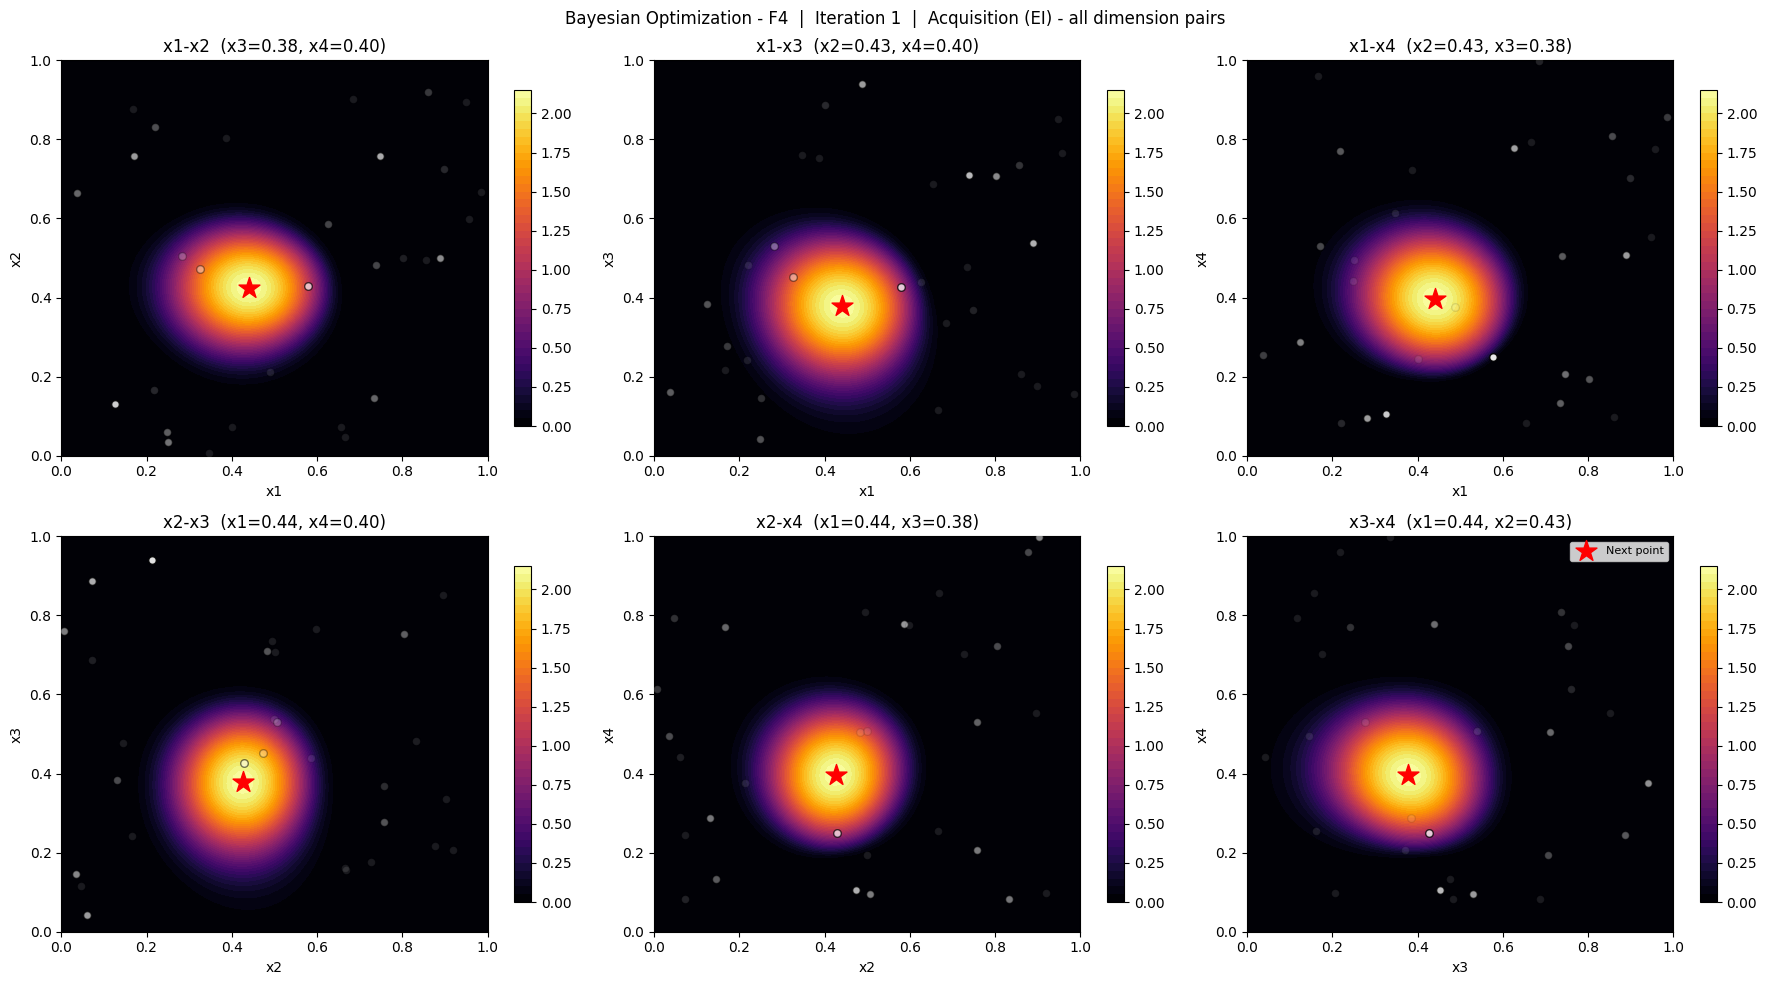

C:\Users\fakep\AppData\Local\Temp\ipykernel_1648\1024251737.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   2  |  xi = 0.08500  |  acq = EI
  Current best y (log)          : 0.636847
  ✅ Suggested x CAPSTONE       : 0.420524-0.417011-0.304188-0.444289
  🎯 Suggested x                : [0.420524, 0.417011, 0.304188, 0.444289]
  📈 Acq. score                 : 0.066699


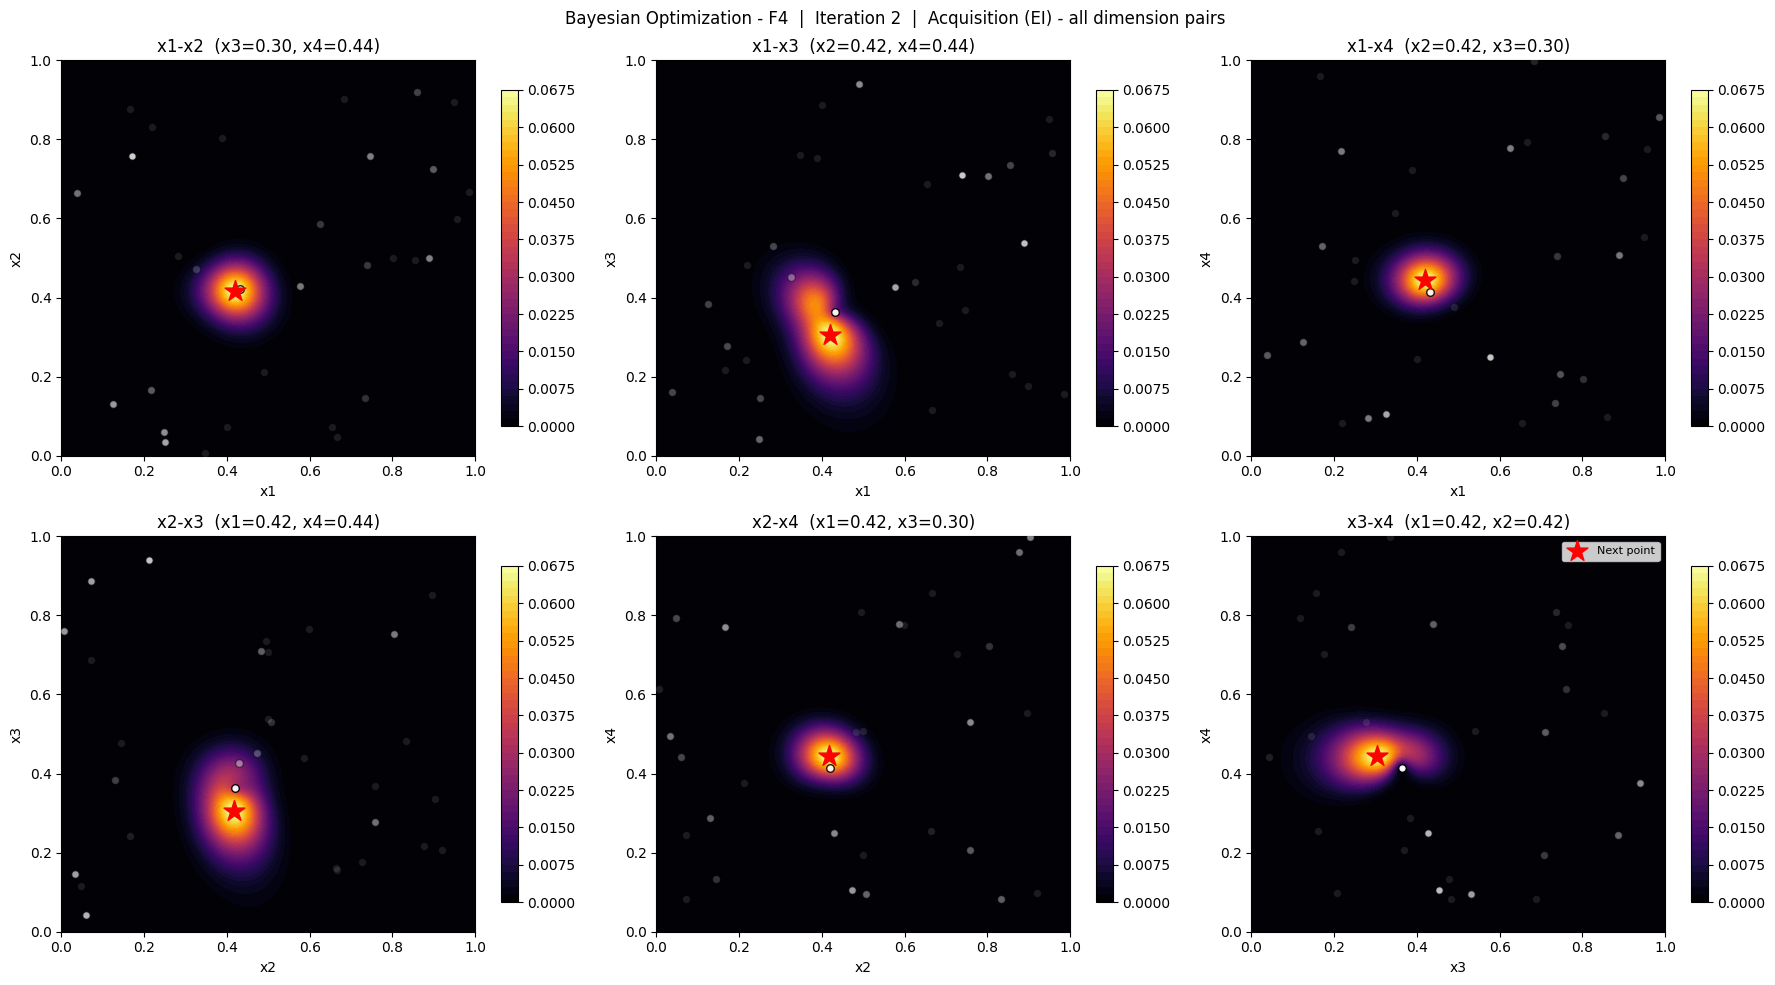

C:\Users\fakep\AppData\Local\Temp\ipykernel_1648\1024251737.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   3  |  xi = 0.07225  |  acq = EI
  Current best y (log)          : 0.636847
  ✅ Suggested x CAPSTONE       : 0.390638-0.418451-0.413912-0.428426
  🎯 Suggested x                : [0.390638, 0.418451, 0.413912, 0.428426]
  📈 Acq. score                 : 0.040729


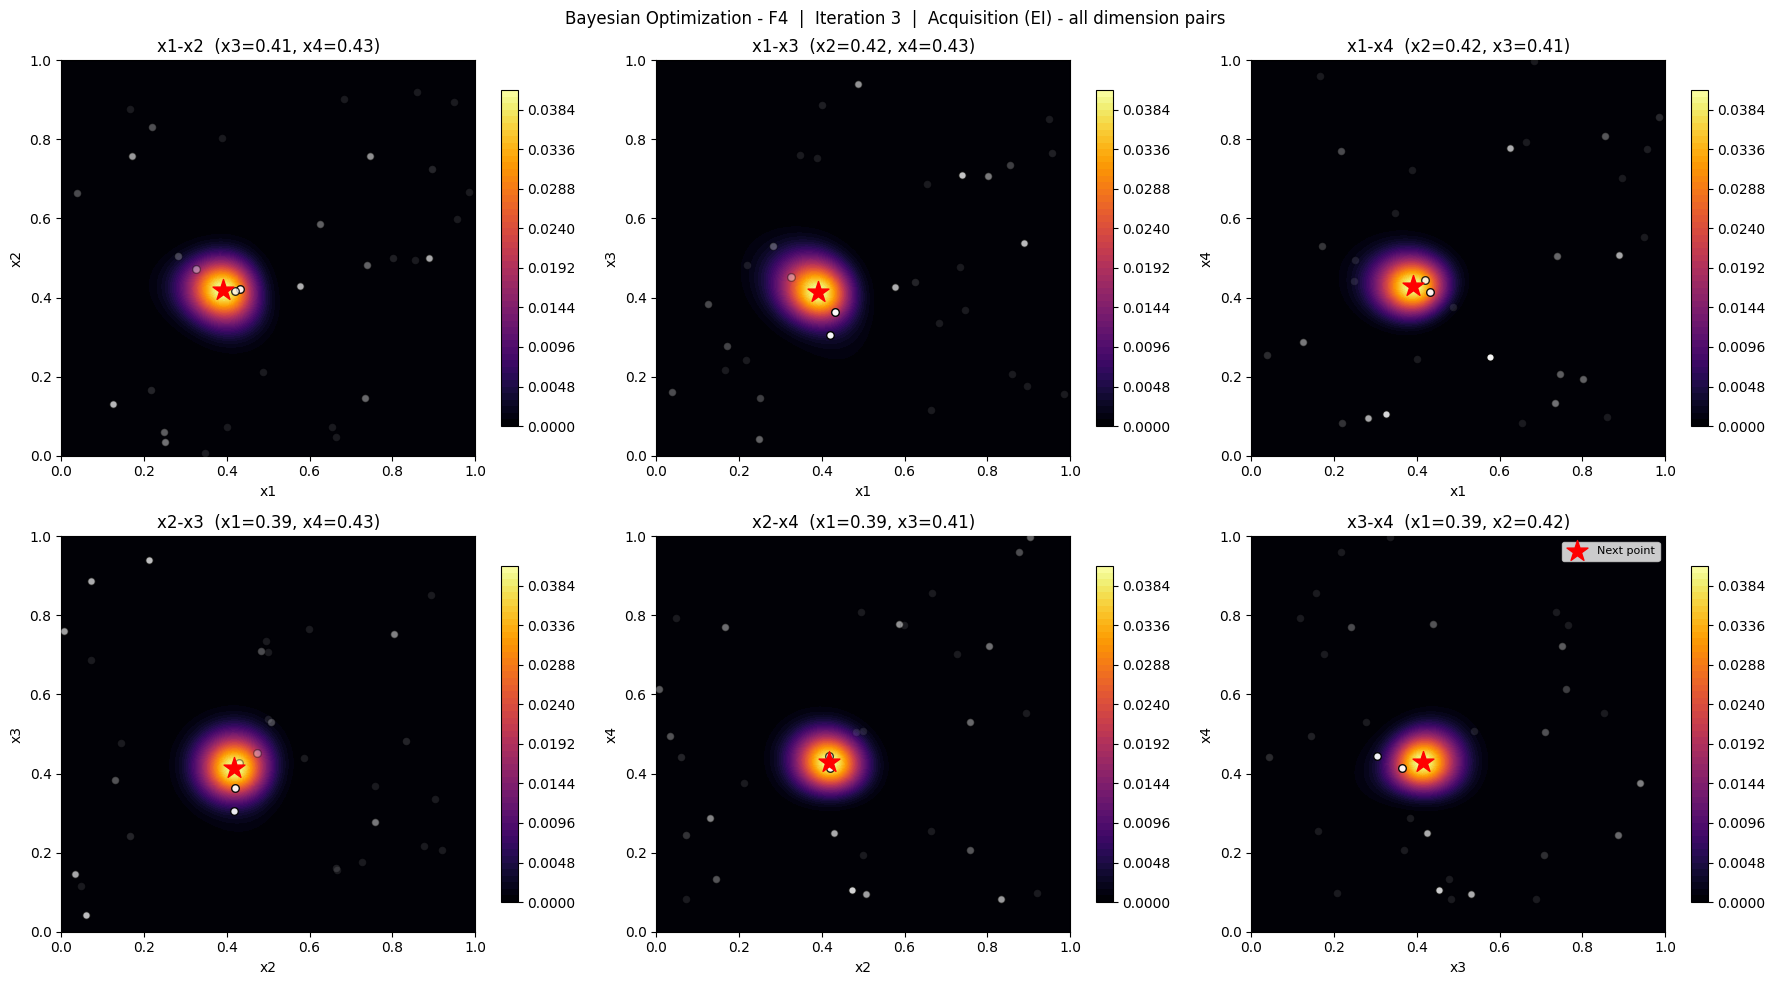

C:\Users\fakep\AppData\Local\Temp\ipykernel_1648\1024251737.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   4  |  xi = 0.06141  |  acq = EI
  Current best y (log)          : 0.636847
  ✅ Suggested x CAPSTONE       : 0.392508-0.422169-0.422725-0.427873
  🎯 Suggested x                : [0.392508, 0.422169, 0.422725, 0.427873]
  📈 Acq. score                 : 0.082469


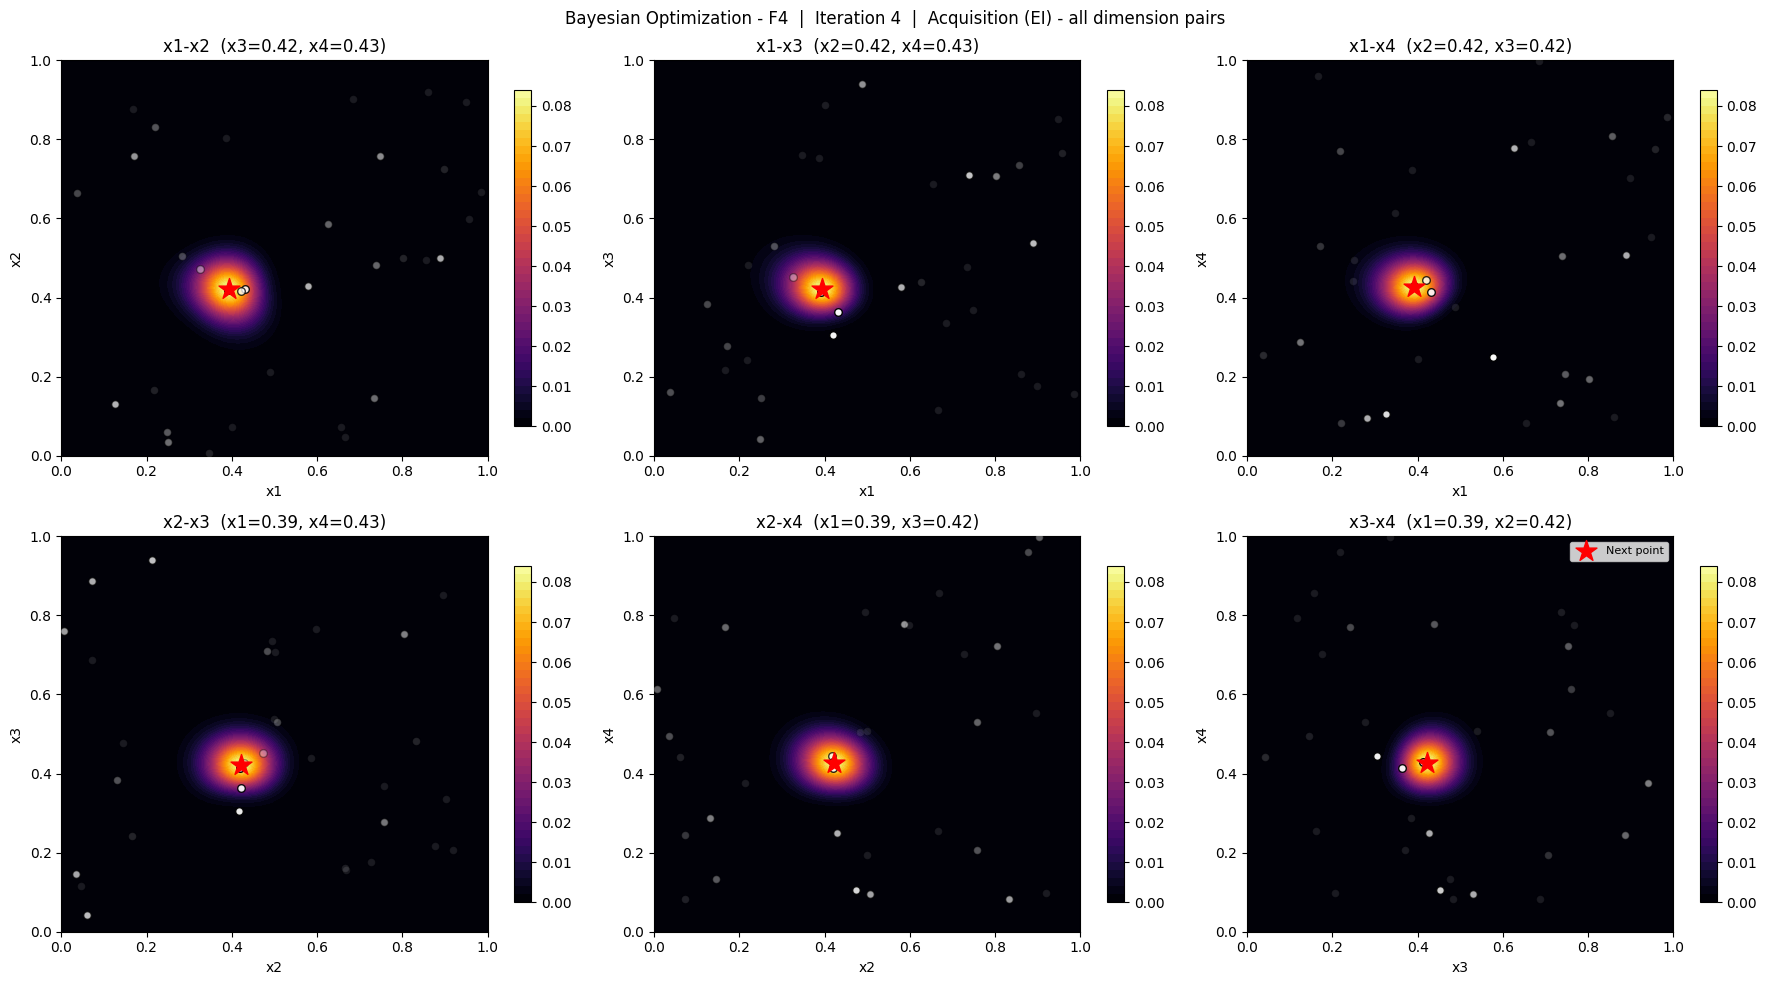

C:\Users\fakep\AppData\Local\Temp\ipykernel_1648\1024251737.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   5  |  xi = 0.05220  |  acq = EI
  Current best y (log)          : 0.636847
  ✅ Suggested x CAPSTONE       : 0.398929-0.423241-0.421175-0.424876
  🎯 Suggested x                : [0.398929, 0.423241, 0.421175, 0.424876]
  📈 Acq. score                 : 0.071918


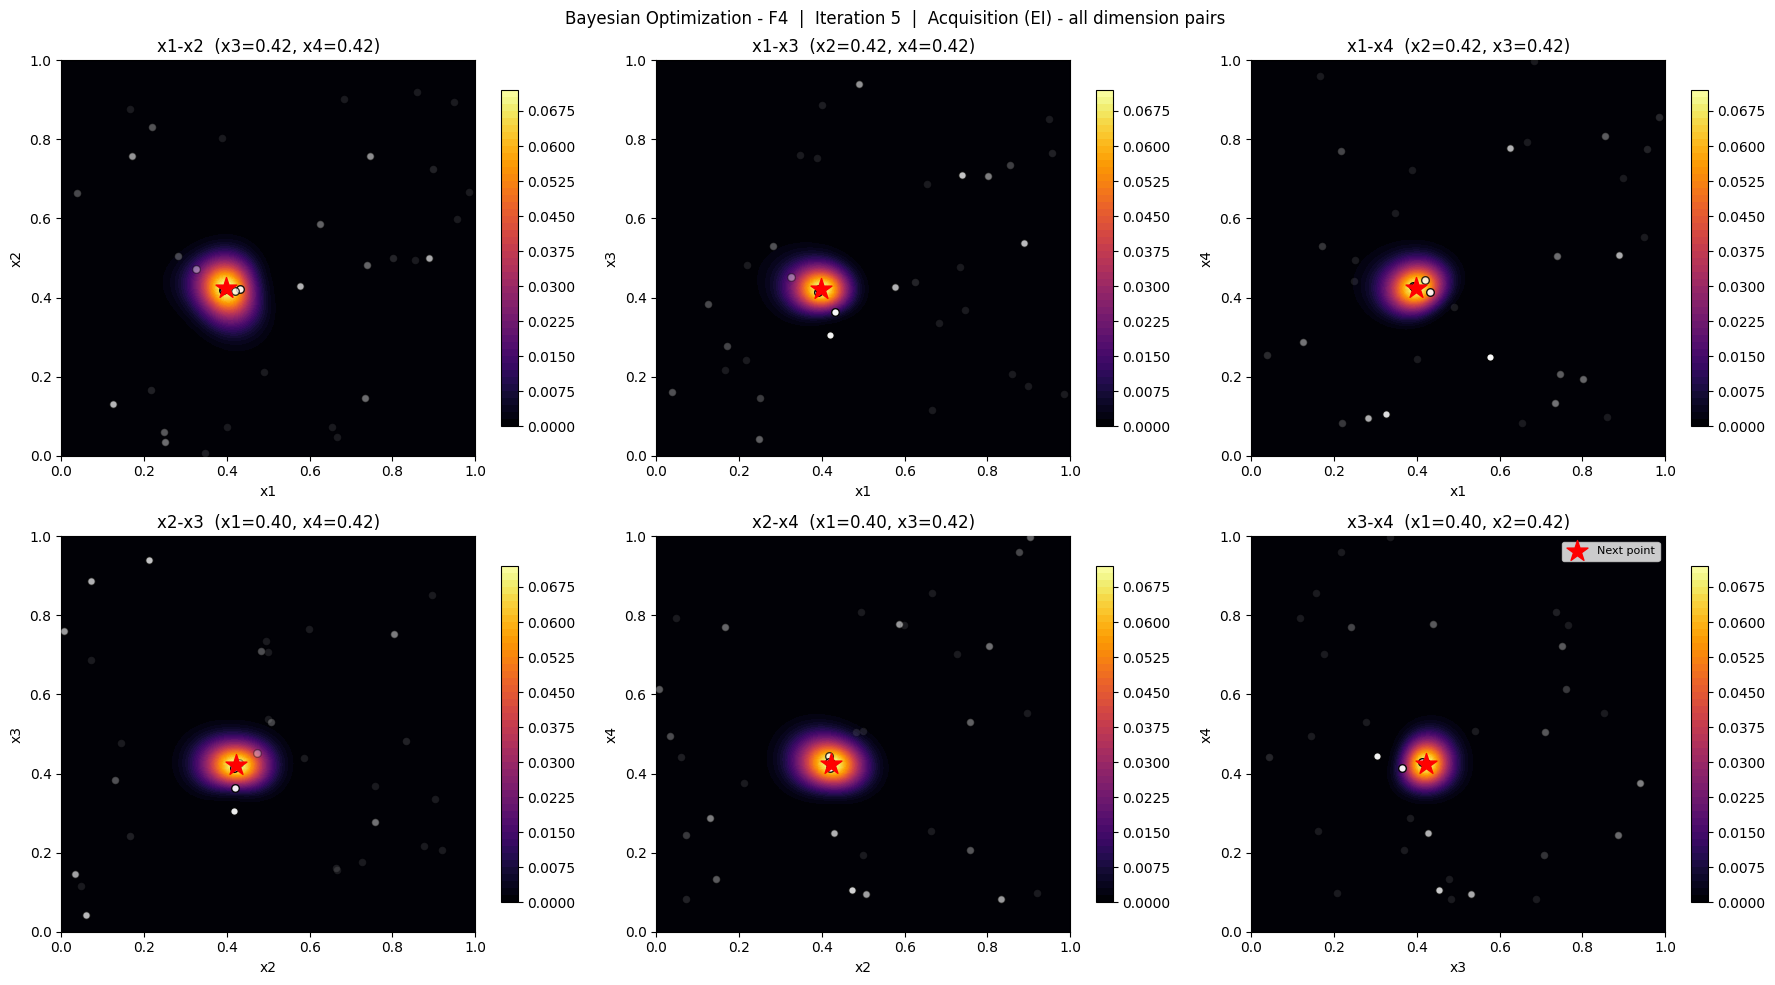

C:\Users\fakep\AppData\Local\Temp\ipykernel_1648\1024251737.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   6  |  xi = 0.04437  |  acq = EI
  Current best y (log)          : 0.636847
  ✅ Suggested x CAPSTONE       : 0.403913-0.421488-0.421369-0.423557
  🎯 Suggested x                : [0.403913, 0.421488, 0.421369, 0.423557]
  📈 Acq. score                 : 0.067247


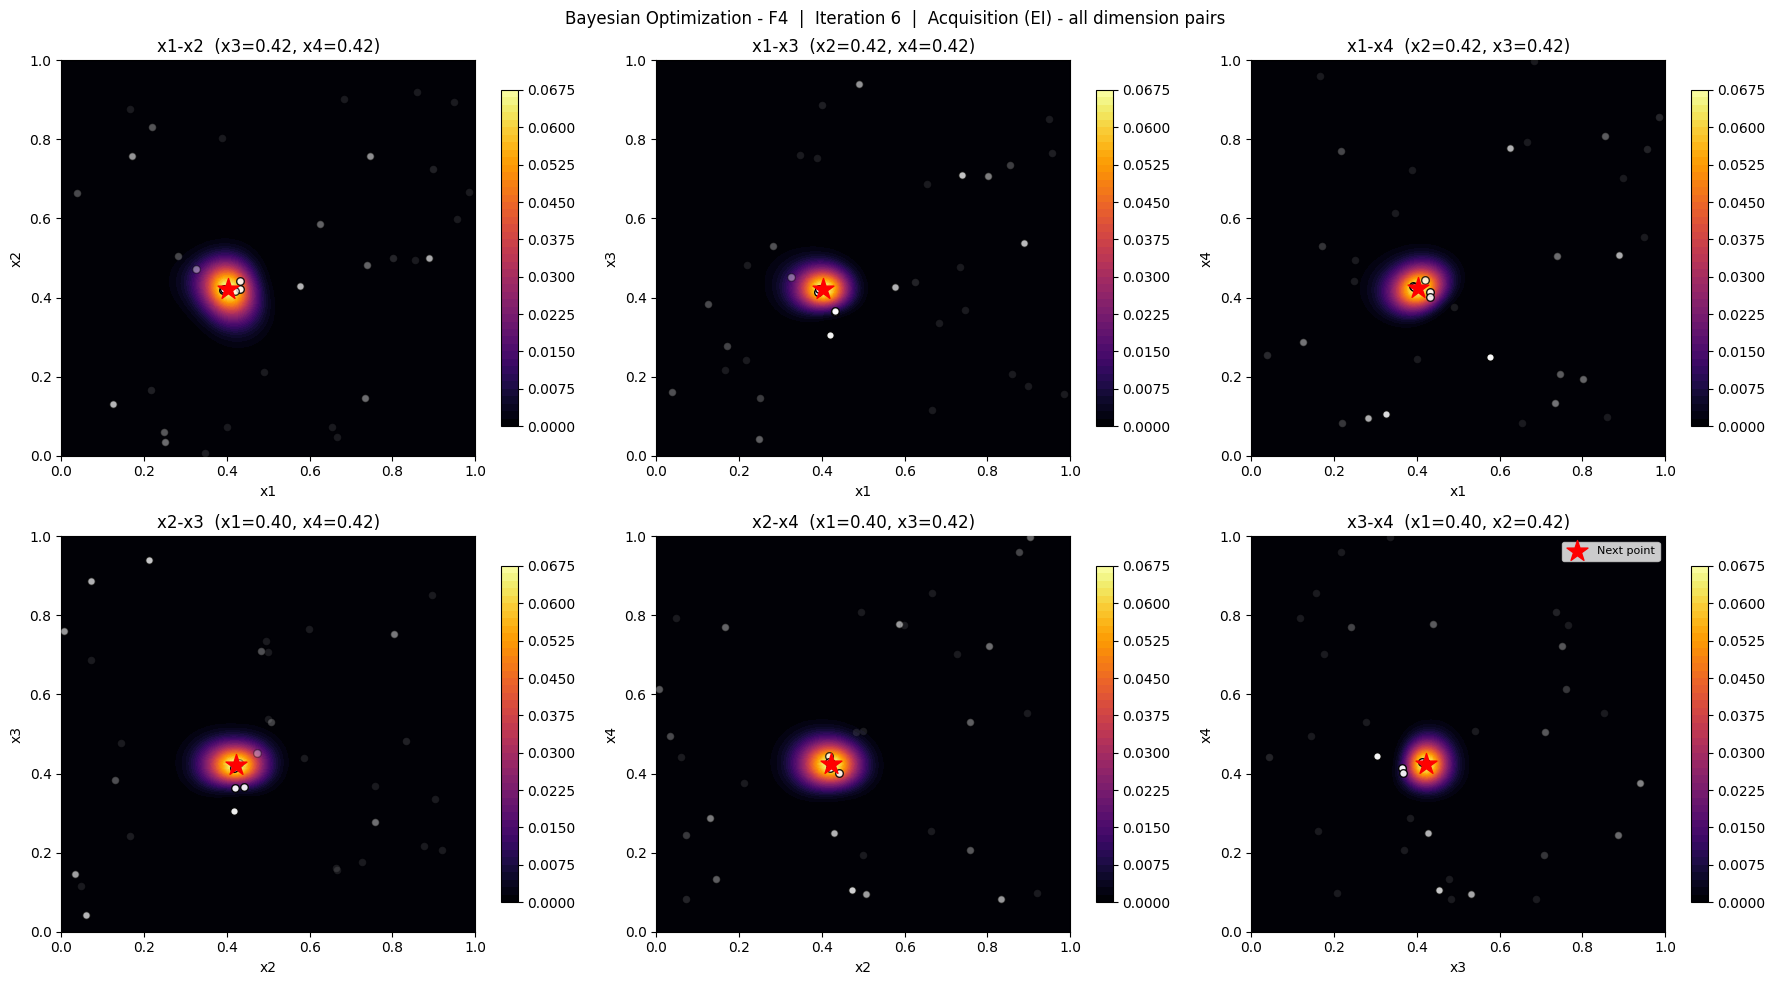

C:\Users\fakep\AppData\Local\Temp\ipykernel_1648\1024251737.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   7  |  xi = 0.03771  |  acq = EI
  Current best y (log)          : 0.668112
  ✅ Suggested x CAPSTONE       : 0.413653-0.415406-0.421129-0.42319
  🎯 Suggested x                : [0.413653, 0.415406, 0.421129, 0.42319]
  📈 Acq. score                 : 0.052085


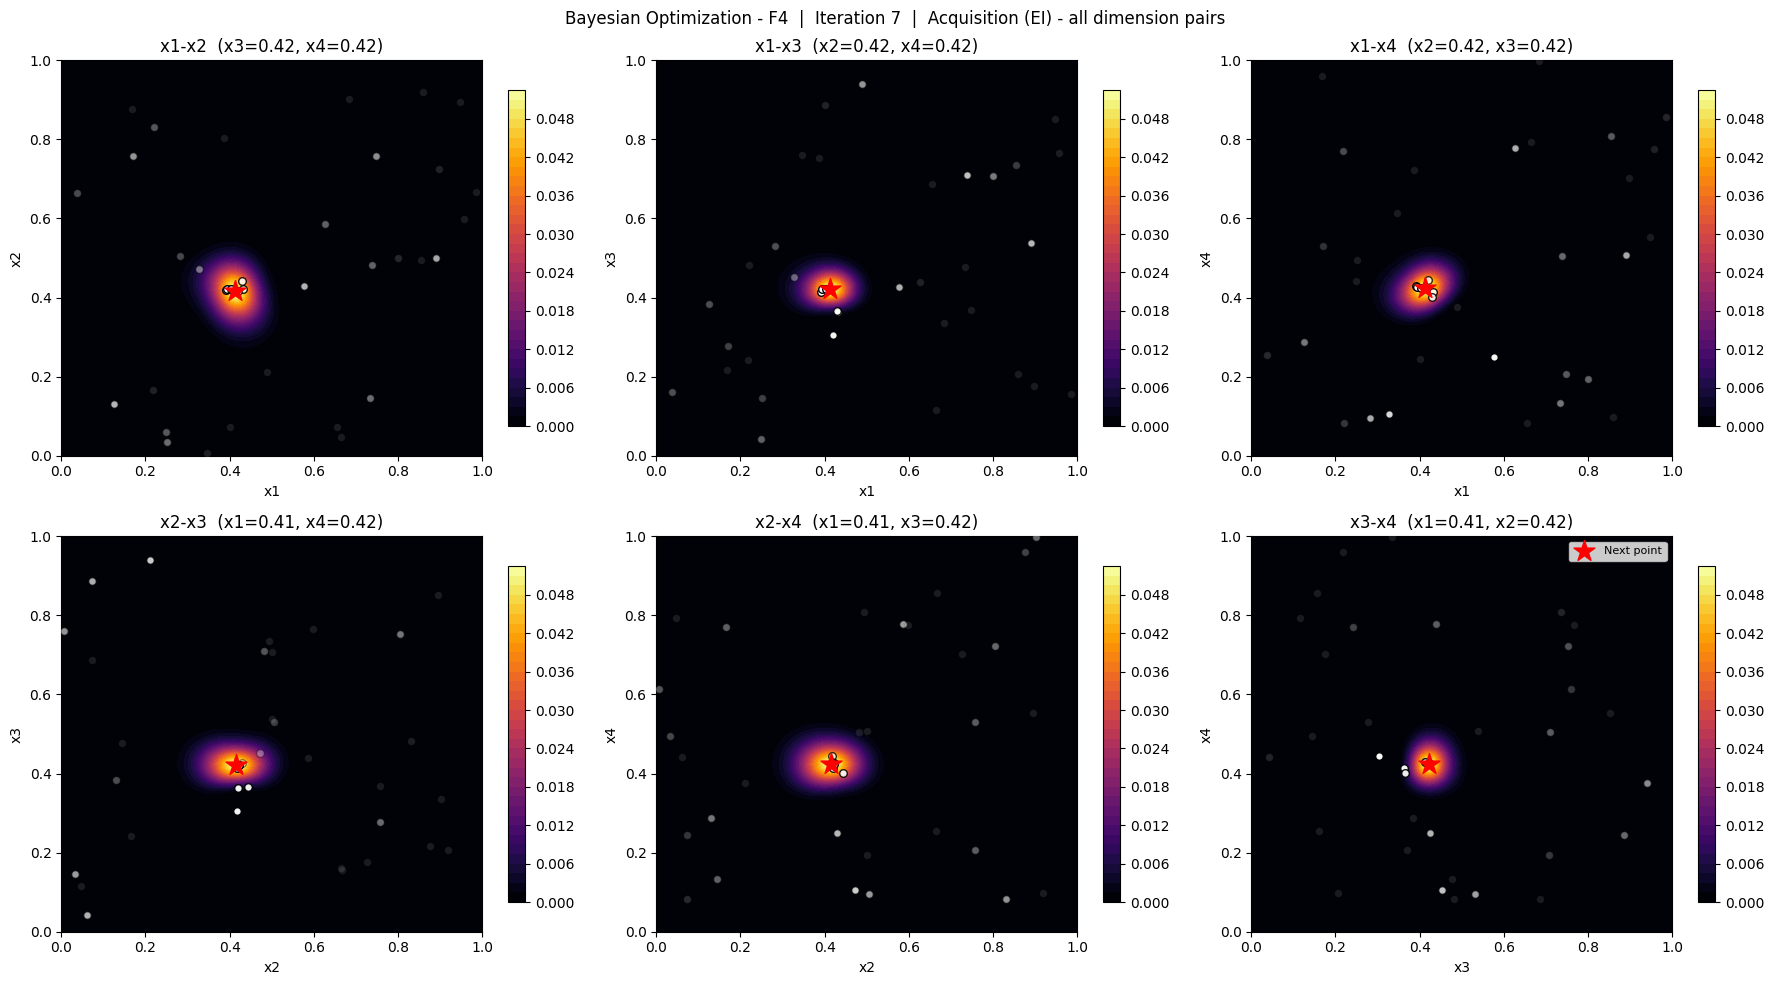

C:\Users\fakep\AppData\Local\Temp\ipykernel_1648\1024251737.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   8  |  xi = 0.03206  |  acq = EI
  Current best y (log)          : 0.668112
  ✅ Suggested x CAPSTONE       : 0.373465-0.435063-0.420743-0.406642
  🎯 Suggested x                : [0.373465, 0.435063, 0.420743, 0.406642]
  📈 Acq. score                 : 0.081227


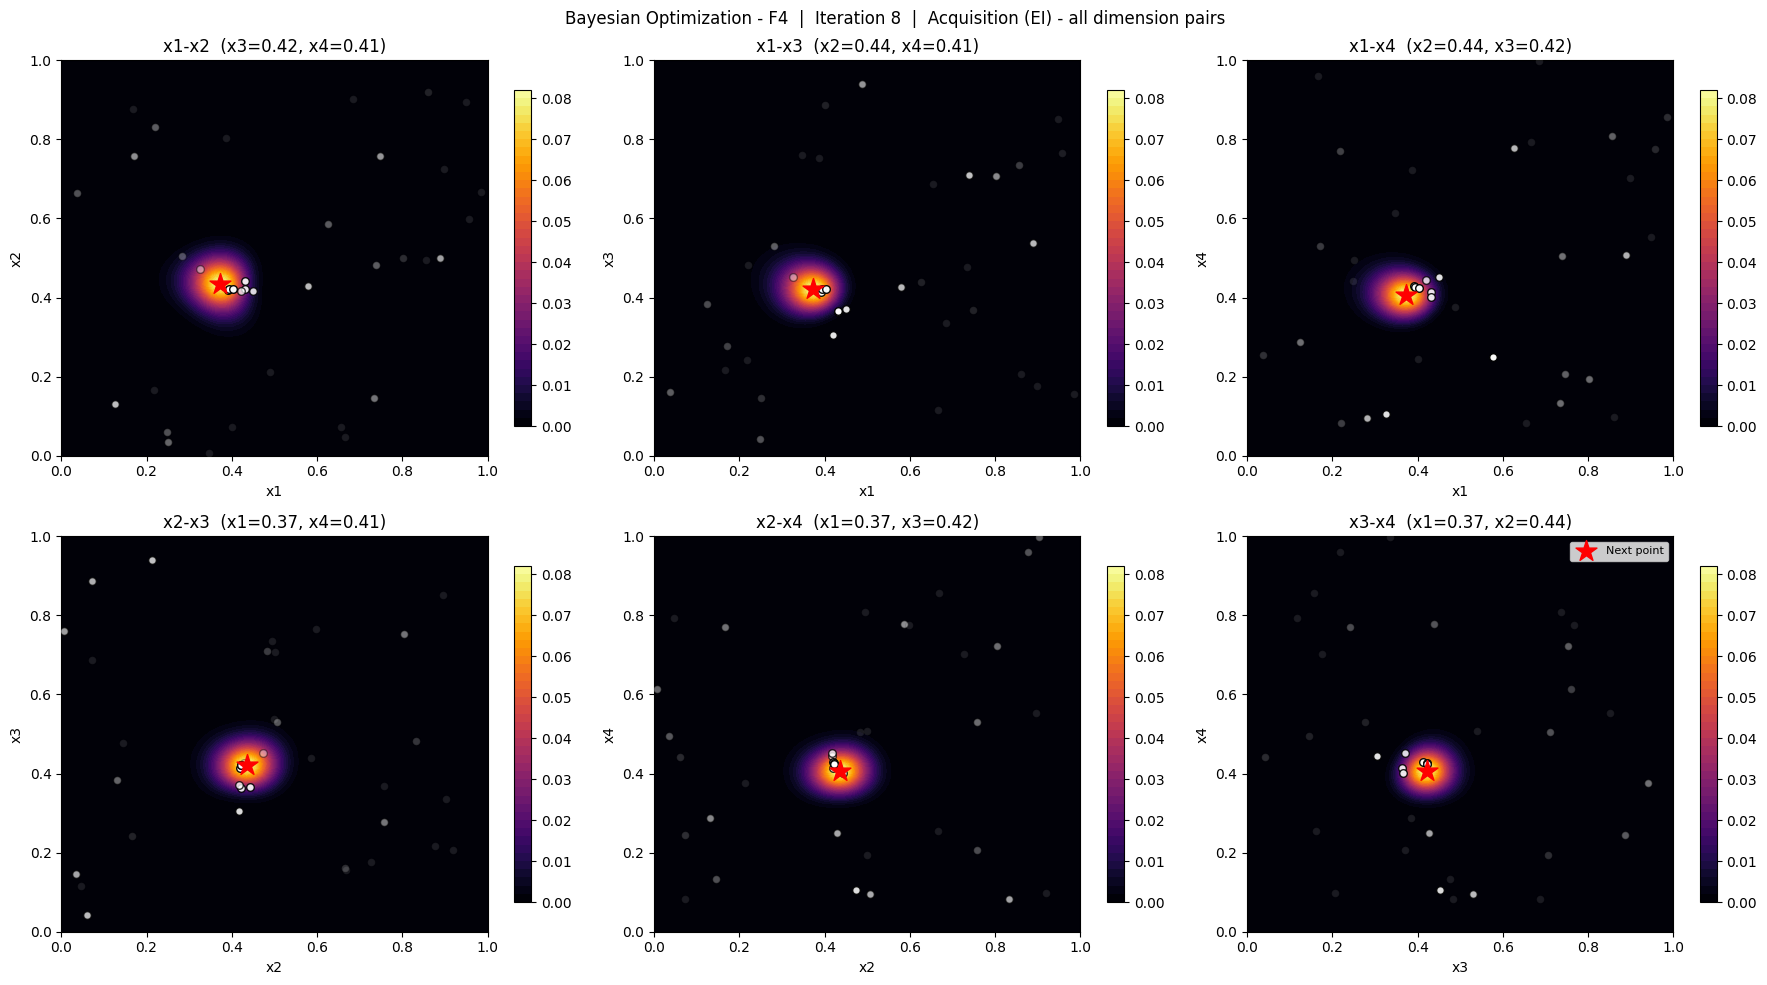

C:\Users\fakep\AppData\Local\Temp\ipykernel_1648\1024251737.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   9  |  xi = 0.02725  |  acq = EI
  Current best y (log)          : 0.668112
  ✅ Suggested x CAPSTONE       : 0.381477-0.426951-0.419073-0.40781
  🎯 Suggested x                : [0.381477, 0.426951, 0.419073, 0.40781]
  📈 Acq. score                 : 0.057159


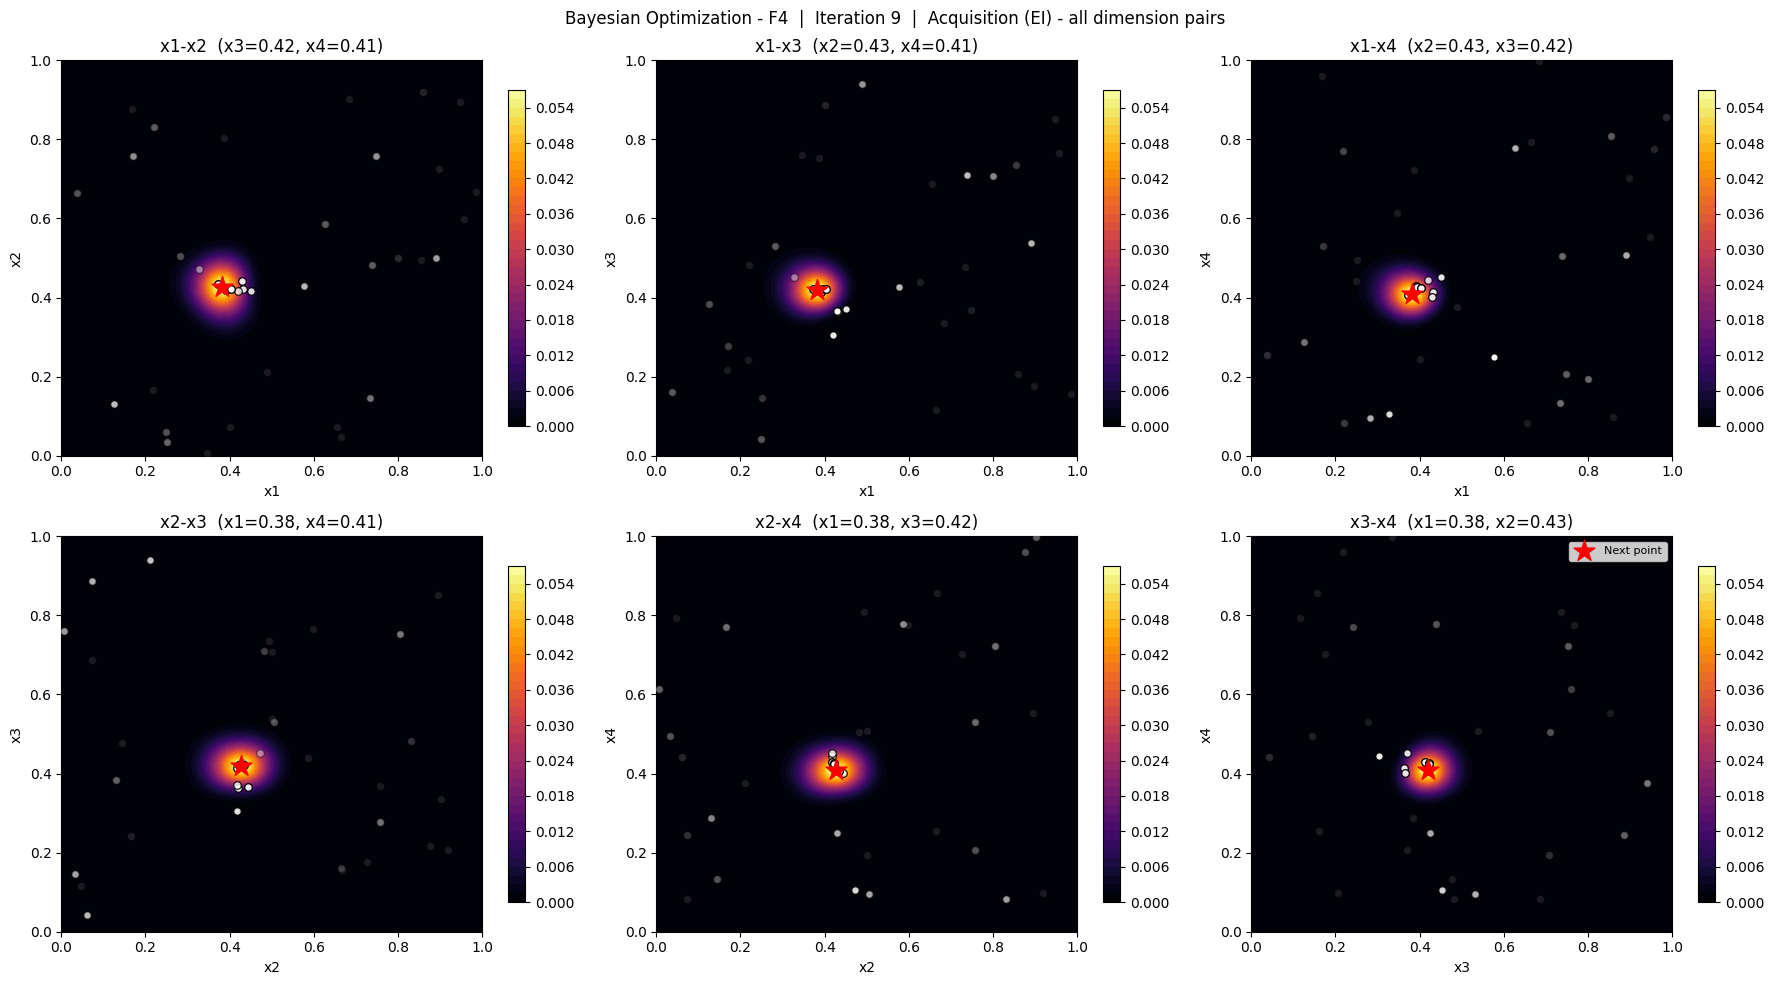

C:\Users\fakep\AppData\Local\Temp\ipykernel_1648\1024251737.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration  10  |  xi = 0.02316  |  acq = EI
  Current best y (log)          : 0.668112
  ✅ Suggested x CAPSTONE       : 0.383699-0.425326-0.418152-0.405938
  🎯 Suggested x                : [0.383699, 0.425326, 0.418152, 0.405938]
  📈 Acq. score                 : 0.050867


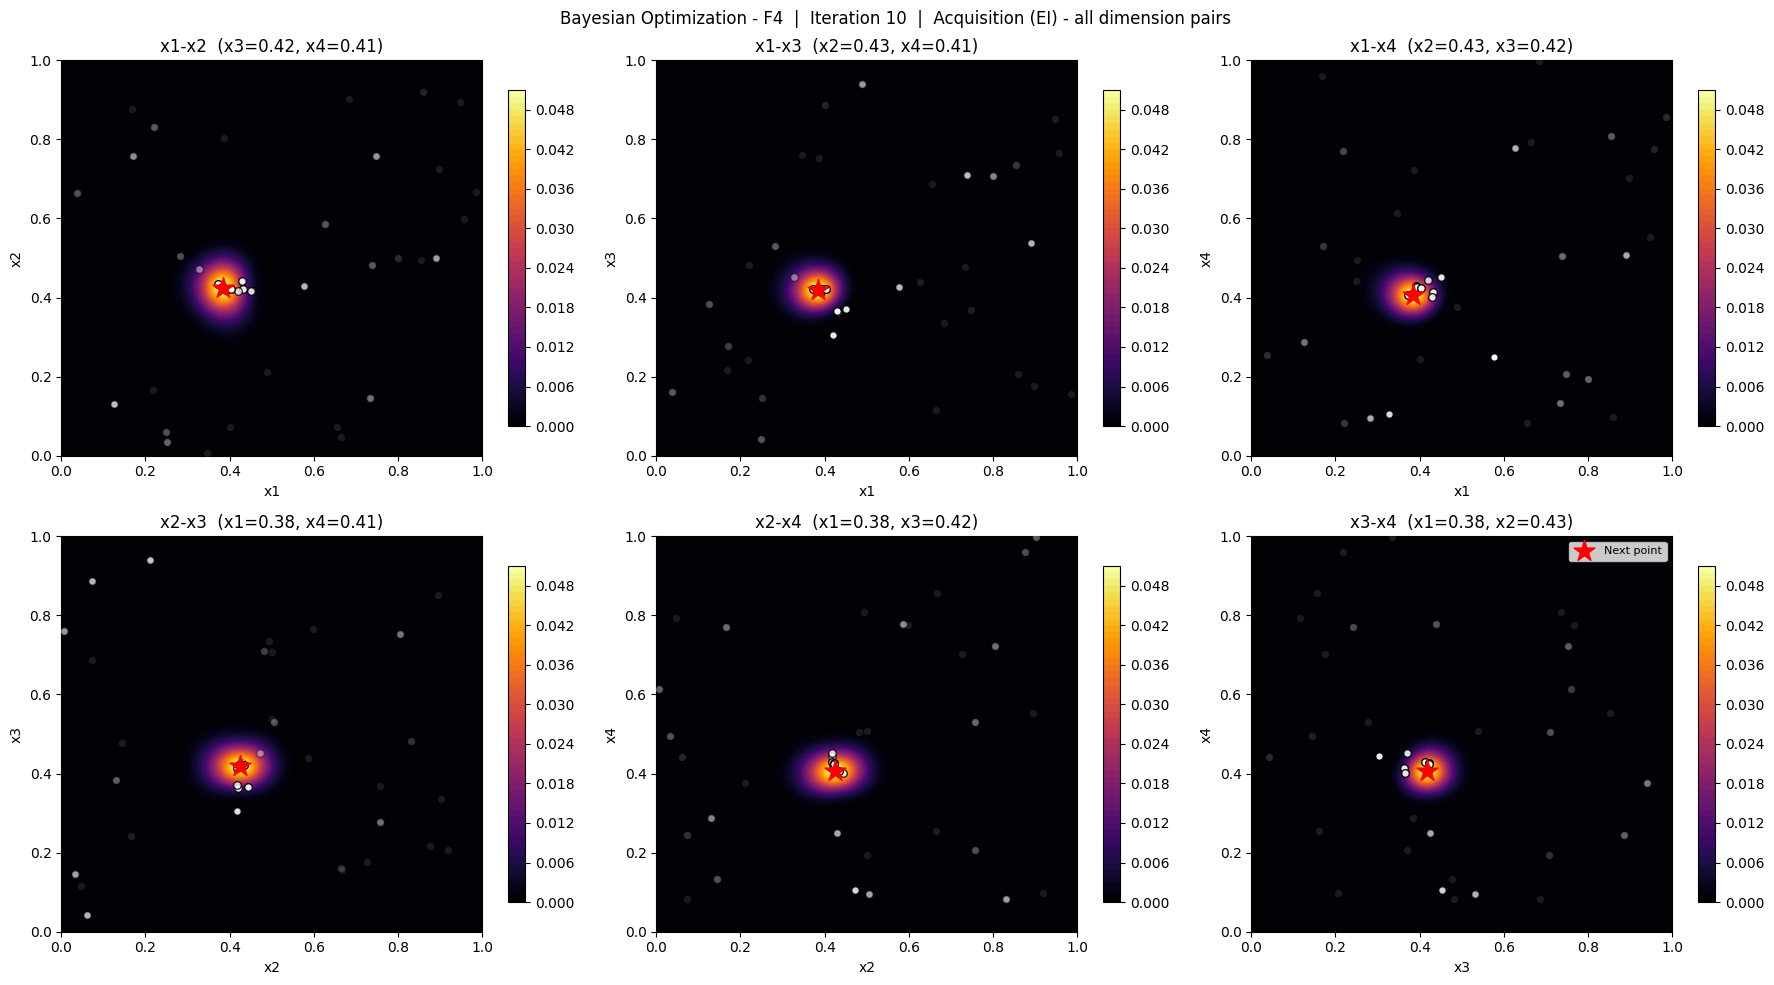

In [7]:
# ── Past Week Data ─────────────────────────────────────────────────────────────
X_new_Data = np.array([]).reshape(0, 4)
y_new_Data = np.array([])

# Week1 addition
X_new_Data = np.vstack([X_new_Data, [0.430937, 0.420549, 0.363639, 0.414536]])
y_new_Data = np.hstack([y_new_Data, 0.63684691015952])

# Week2 addition
X_new_Data = np.vstack([X_new_Data, [0.420524, 0.417010, 0.304188, 0.444288]])
y_new_Data = np.hstack([y_new_Data, -0.6777287175759379])

# Week3 addition
X_new_Data = np.vstack([X_new_Data, [0.390874, 0.418464, 0.413572, 0.428353]])
y_new_Data = np.hstack([y_new_Data, 0.5839107123028957])

# Week4 addition
X_new_Data = np.vstack([X_new_Data, [0.392627, 0.422150, 0.422542, 0.427834]])
y_new_Data = np.hstack([y_new_Data, 0.5856414609747032])

# Week5 addition
X_new_Data = np.vstack([X_new_Data, [0.430619, 0.442553, 0.365855, 0.400203]])
y_new_Data = np.hstack([y_new_Data, 0.2751990280648795])

# Week6 addition
X_new_Data = np.vstack([X_new_Data, [0.403912, 0.421488, 0.421369, 0.423557]])
y_new_Data = np.hstack([y_new_Data, 0.668111819264603])

# Week7 addition
X_new_Data = np.vstack([X_new_Data, [0.450385, 0.417175, 0.370644, 0.451494]])
y_new_Data = np.hstack([y_new_Data, -0.30410880515120153])

# Week8 addition
X_new_Data = np.vstack([X_new_Data, [0.373589, 0.434972, 0.420710, 0.406682]])
y_new_Data = np.hstack([y_new_Data, 0.4983388859814899])

# Week9 addition
X_new_Data = np.vstack([X_new_Data, [0.381534, 0.426949, 0.419053, 0.407843]])
y_new_Data = np.hstack([y_new_Data, 0.5789582447621631])

# -- Configuration -------------------------------------------------------------
N_ITER   = len(y_new_Data)+1       # number of BO steps to run
ACQ      = "ei"    # "ei" or "ucb"
XI_INIT  = 0.1     # matches original F4 xi -- high exploration justified by large EI
XI_DECAY = 0.85
KAPPA    = 2.576   # only used if ACQ = "ucb"

# -- History (seeded with initial observations) --------------------------------
X_obs        = X.copy()
y_obs        = y.copy()
history_best = [y_obs.max()]

for iteration in range(N_ITER):

    # 1. Fit GP on raw outputs (no transform needed for F4)
    gp    = build_gp(n_dim)
    gp.fit(X_obs, y_obs)
    y_max = y_obs.max()

    # 2. Compute adaptive xi for this iteration
    xi = adaptive_xi(iteration, xi_init=XI_INIT, decay=XI_DECAY)

    # 3. Define acquisition callable for the plot helper
    if ACQ == "ucb":
        acq_fn    = lambda X_c: upper_confidence_bound(X_c, gp, kappa=KAPPA)
        acq_label = "UCB"
    else:
        acq_fn    = lambda X_c: expected_improvement(X_c, gp, y_max, xi=xi)
        acq_label = "EI"

    # 4. Suggest next point
    x_next, score = suggest_next_point(
        gp, y_max, n_dim,
        xi=xi, acq=ACQ, kappa=KAPPA,
        seed=SEED + iteration
    )

    # 5. Print summary
    print("\n" + "="*62)
    print(f"  Iteration {iteration + 1:>3d}  |  xi = {xi:.5f}  |  acq = {acq_label}")
    print(f"  Current best y (log)          : {y_max:.6f}")
    print(f"  ✅ Suggested x CAPSTONE       : {np.round(x_next[0], 6)}-{np.round(x_next[1], 6)}-{np.round(x_next[2], 6)}-{np.round(x_next[3], 6)}")
    print(f"  🎯 Suggested x                : {np.round(x_next, 6).tolist()}")
    print(f"  📈 Acq. score                 : {score:.6f}")
    print("="*62)

    # 6. Visualise acquisition slices -- all 6 dimension pairs
    plot_slices_4d(gp, X_obs, x_next, acq_fn,
                   iteration=iteration + 1, acq_label=acq_label)

    # ── PAST WEEKS DATA ──────────────────────────────────────────────
    if iteration < len(y_new_Data):
        y_new  = y_new_Data[iteration]
        X_obs  = np.vstack([X_obs, X_new_Data[iteration]])
        y_obs  = np.append(y_obs, y_new)
        history_best.append(y_obs.max())
    # ─────────────────────────────────────────────────────────────────────────

## 8. SVM classifier on observed data

In [8]:
# Threshold: top 25% of log-transformed observations = "high"
threshold = np.percentile(y_obs, 75)
labels = (y_obs >= threshold).astype(int)  # 1 = high, 0 = low

print(f"Threshold (75th pct, log-space): {threshold:.4f}")
print(f"High-performing points : {labels.sum()} / {len(labels)}")

# Scale inputs (SVM is sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_obs)

# Soft-margin SVM with RBF kernel (handles non-linear boundaries)
# C controls margin softness: lower C = wider margin, more generalisation
# gamma='scale' = 1/(n_features * X.var()), a robust default
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
svm.fit(X_scaled, labels)

print(f"\nSVM kernel  : {svm.kernel}")
print(f"Support vectors : {svm.n_support_} (class 0 / class 1)")

Threshold (75th pct, log-space): -5.3638
High-performing points : 10 / 39

SVM kernel  : rbf
Support vectors : [10  6] (class 0 / class 1)


## 9. Visualise the SVM decision boundary alongside GP

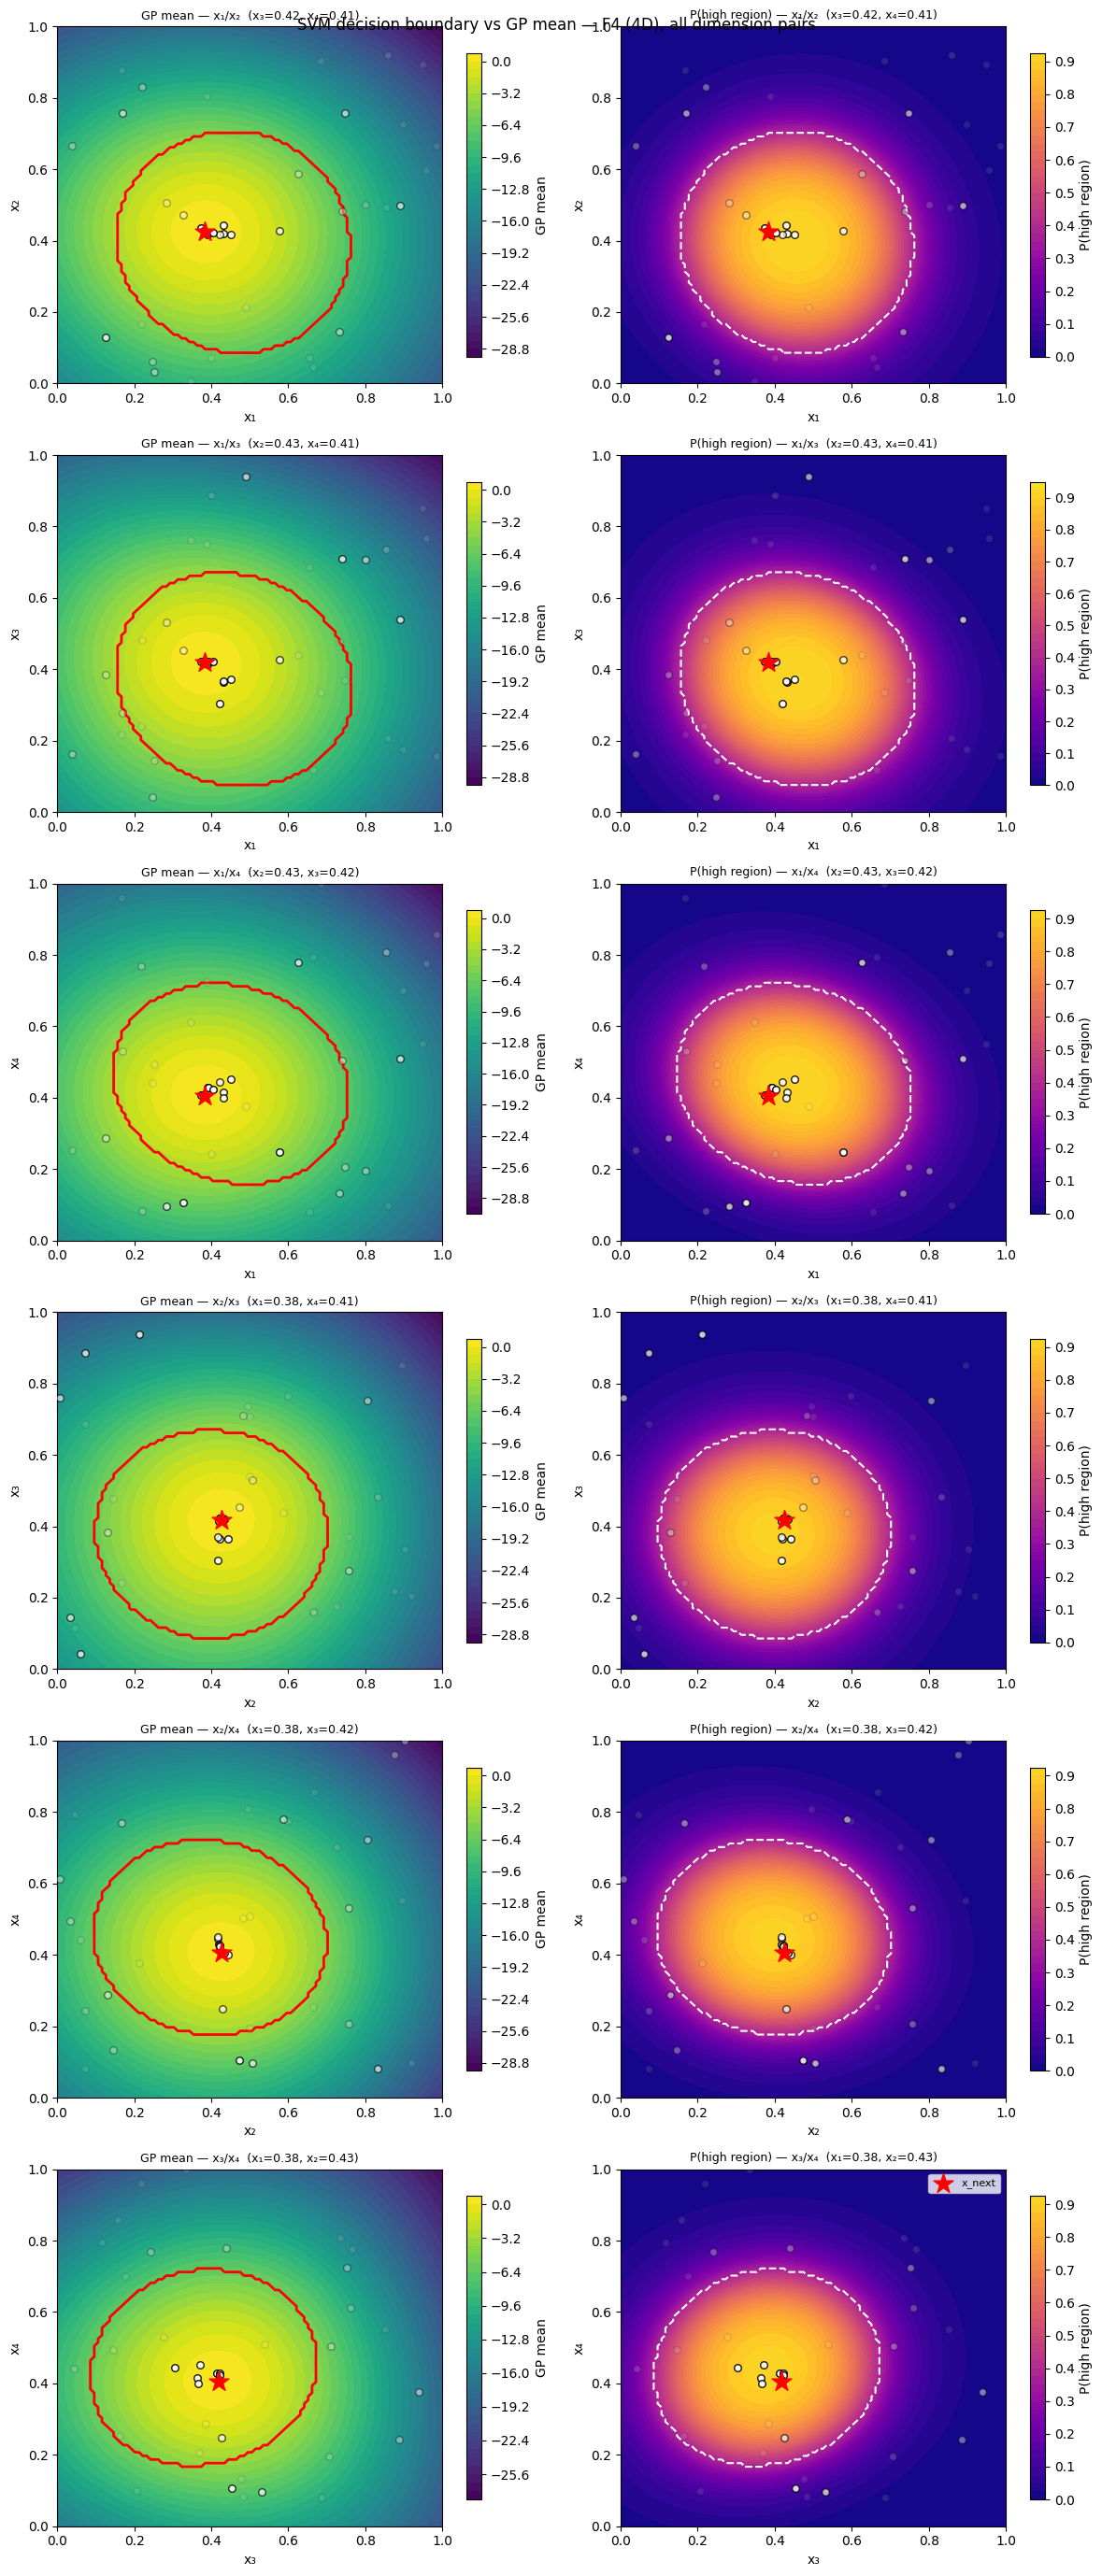

In [9]:
# ── Plot: SVM probability slices — all 6 dimension pairs (4D) ────────────────
from itertools import combinations

resolution = 100
grid_1d    = np.linspace(0, 1, resolution)
G1, G2     = np.meshgrid(grid_1d, grid_1d)
flat1, flat2 = G1.ravel(), G2.ravel()

dim_labels = ["x₁", "x₂", "x₃", "x₄"]
dim_pairs  = list(combinations(range(4), 2))   # 6 pairs

fig, axes = plt.subplots(6, 2, figsize=(12, 28))  # 6 rows × 2 cols
fig.suptitle("SVM decision boundary vs GP mean — F4 (4D), all dimension pairs", fontsize=12)

for row, (d0, d1) in enumerate(dim_pairs):
    fixed_dims = [d for d in range(4) if d not in (d0, d1)]

    # Build 4-column grid: sweep d0 & d1, fix the other two at x_next values
    X_grid = np.tile(x_next, (resolution * resolution, 1))
    X_grid[:, d0] = flat1
    X_grid[:, d1] = flat2

    # GP mean
    mu_slice, _ = gp.predict(X_grid, return_std=True)
    mu_slice     = mu_slice.reshape(resolution, resolution)

    # SVM predictions
    X_grid_scaled  = scaler.transform(X_grid)
    svm_prob_slice = svm.predict_proba(X_grid_scaled)[:, 1].reshape(resolution, resolution)
    svm_pred_slice = svm.predict(X_grid_scaled).reshape(resolution, resolution)

    # Opacity: average proximity across both fixed dims
    dist   = np.mean([np.abs(X_obs[:, fd] - x_next[fd]) for fd in fixed_dims], axis=0)
    alphas = np.clip(1.0 - dist / 0.3, 0.1, 1.0)
    fix_str = ", ".join(f"{dim_labels[fd]}={x_next[fd]:.2f}" for fd in fixed_dims)

    # Left column: GP mean + SVM boundary
    ax = axes[row, 0]
    im = ax.contourf(G1, G2, mu_slice, levels=40, cmap="viridis")
    fig.colorbar(im, ax=ax, shrink=0.85, label="GP mean")
    ax.contour(G1, G2, svm_pred_slice, levels=[0.5], colors="red", linewidths=2)
    for xi_obs, yi_obs, a in zip(X_obs[:, d0], X_obs[:, d1], alphas):
        ax.scatter(xi_obs, yi_obs, c="white", edgecolors="black",
                   s=30, alpha=float(a), zorder=5)
    ax.scatter(x_next[d0], x_next[d1], c="red", marker="*", s=250, zorder=6)
    ax.set_title(f"GP mean — {dim_labels[d0]}/{dim_labels[d1]}  ({fix_str})", fontsize=9)
    ax.set_xlabel(dim_labels[d0]); ax.set_ylabel(dim_labels[d1])

    # Right column: SVM P(high)
    ax = axes[row, 1]
    im2 = ax.contourf(G1, G2, svm_prob_slice, levels=40, cmap="plasma", vmin=0, vmax=1)
    fig.colorbar(im2, ax=ax, shrink=0.85, label="P(high region)")
    ax.contour(G1, G2, svm_pred_slice, levels=[0.5], colors="white",
               linewidths=1.5, linestyles="--")
    for xi_obs, yi_obs, a in zip(X_obs[:, d0], X_obs[:, d1], alphas):
        ax.scatter(xi_obs, yi_obs, c="white", edgecolors="black",
                   s=30, alpha=float(a), zorder=5)
    ax.scatter(x_next[d0], x_next[d1], c="red", marker="*", s=250,
               zorder=6, label="x_next")
    ax.set_title(f"P(high region) — {dim_labels[d0]}/{dim_labels[d1]}  ({fix_str})", fontsize=9)
    ax.set_xlabel(dim_labels[d0]); ax.set_ylabel(dim_labels[d1])

axes[-1, 1].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("svm_boundary_f4.png", dpi=150)
plt.show()

## 10. SVM-constrained next point suggestion

In [10]:
# ── Constrained BO: suggest next point inside SVM "high" region ──────────────
from scipy.stats import qmc

# Generate a large Sobol candidate set
sampler = qmc.Sobol(d=n_dim, scramble=True, seed=SEED + 99)
X_cand = sampler.random(20_000)

# Keep only candidates the SVM classifies as "high"
X_cand_scaled = scaler.transform(X_cand)
svm_labels    = svm.predict(X_cand_scaled)
svm_probs     = svm.predict_proba(X_cand_scaled)[:, 1]

# Filter: inside SVM high region AND probability > 0.5
mask = (svm_labels == 1) & (svm_probs > 0.5)
X_constrained = X_cand[mask]

print(f"Candidates in high region : {mask.sum()} / {len(X_cand)} "
      f"({100*mask.mean():.1f}% of space)")

if len(X_constrained) < 10:
    # Fallback: boundary too restrictive, use full candidate set
    print("⚠️  Fewer than 10 constrained candidates — falling back to full set.")
    X_constrained = X_cand

# Score with EI inside the constrained region only
xi_constrained = adaptive_xi(N_ITER, xi_init=XI_INIT, decay=XI_DECAY)
ei_scores = expected_improvement(X_constrained, gp, y_obs.max(), xi=xi_constrained)

# Local optimisation from top-8 starts within the constrained region
starts = X_constrained[np.argsort(ei_scores)[-8:]]
bounds = [(0, 1)] * n_dim
obj    = lambda x: -expected_improvement(x, gp, y_obs.max(), xi=xi_constrained).item()

best_x_svm, best_score_svm = None, -np.inf
for x0 in starts:
    res = minimize(obj, x0=x0, bounds=bounds, method="L-BFGS-B")
    if -res.fun > best_score_svm:
        best_score_svm = -res.fun
        best_x_svm     = res.x

print(f"\n{'='*55}")
print(f"  SVM-constrained suggestion")
print(f"  Suggested x : {np.round(best_x_svm, 6).tolist()}")
print(f"  EI score    : {best_score_svm:.6f}")
print(f"  xi used     : {xi_constrained:.5f}")
print(f"  ✅ CAPSTONE format : {np.round(best_x_svm[0],6)}-{np.round(best_x_svm[1],6)}-{np.round(best_x_svm[2],6)}-{np.round(best_x_svm[3],6)}")
print(f"{'='*55}")

C:\Users\fakep\AppData\Local\Temp\ipykernel_1648\593739079.py:6: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand = sampler.random(20_000)


Candidates in high region : 535 / 20000 (2.7% of space)

  SVM-constrained suggestion
  Suggested x : [0.383733, 0.425344, 0.41814, 0.405971]
  EI score    : 0.052053
  xi used     : 0.01969
  ✅ CAPSTONE format : 0.383733-0.425344-0.41814-0.405971


## 11. Neural Network Surrogate (MC Dropout)

We use a **PyTorch MLP with Monte Carlo Dropout** as a third surrogate. Unlike the GP (which has a closed-form posterior) or the SVM (which only classifies regions), the NN learns a direct regression mapping from input to output.

**Why MC Dropout for uncertainty?**
Dropout randomly zeroes neurons during training to prevent co-adaptation. At inference time, keeping dropout *active* and running multiple forward passes produces a distribution of predictions — the mean is the surrogate's prediction and the standard deviation is its uncertainty estimate (Gal & Ghahramani, 2016).

**Architecture:**
- 2 hidden layers of 32 units with ReLU activations
- Dropout rate = 0.1 between each layer
- Trained with Adam + L2 weight decay on normalised targets
- Uncertainty = std across 200 stochastic forward passes

> **F4 note:** 4D input, 33 training points, raw y values (normalised to N(0,1)). The visualisation uses the same 2×3 slice grid as the GP plots, covering all 6 dimension pairs.

In [11]:
class MCDropoutNN(nn.Module):
    """MLP with dropout kept active at inference for uncertainty quantification."""

    def __init__(self, n_in, hidden=32, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

    def mc_predict(self, x_tensor, n_samples=200):
        """n_samples stochastic forward passes → (mean, std) as numpy arrays."""
        self.train()   # keep dropout active during inference
        with torch.no_grad():
            preds = torch.stack([self(x_tensor) for _ in range(n_samples)])
        return preds.mean(0).numpy(), preds.std(0).numpy()


# ── Normalise inputs and targets ──────────────────────────────────────────────
scaler_nn = StandardScaler()
X_nn      = scaler_nn.fit_transform(X_obs)

y_nn_mean = y_obs.mean()
y_nn_std  = max(y_obs.std(), 1e-8)
y_nn      = (y_obs - y_nn_mean) / y_nn_std   # N(0,1) targets

X_t = torch.tensor(X_nn, dtype=torch.float32)
y_t = torch.tensor(y_nn, dtype=torch.float32)

# ── Train ─────────────────────────────────────────────────────────────────────
torch.manual_seed(SEED)
nn_model  = MCDropoutNN(n_dim, hidden=32, dropout=0.1)
optimizer = optim.Adam(nn_model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn   = nn.MSELoss()

nn_model.train()
for epoch in range(3000):
    optimizer.zero_grad()
    loss = loss_fn(nn_model(X_t), y_t)
    loss.backward()
    optimizer.step()

print(f"NN trained — final MSE loss: {loss.item():.6f}")

# ── Sanity check on training data ─────────────────────────────────────────────
mu_chk, sig_chk = nn_model.mc_predict(X_t, n_samples=200)
mu_chk_raw = mu_chk * y_nn_std + y_nn_mean
print(f"NN mean pred range (raw) : [{mu_chk_raw.min():.4f}, {mu_chk_raw.max():.4f}]")
print(f"NN uncertainty std range : [{sig_chk.min():.4f},  {sig_chk.max():.4f}]")

NN trained — final MSE loss: 0.015936
NN mean pred range (raw) : [-32.6801, 0.4155]
NN uncertainty std range : [0.0325,  0.2365]


## 12. NN-constrained next point suggestion

We define EI using the MC-Dropout NN's predicted mean (μ) and standard deviation (σ), then run the same Sobol + L-BFGS-B optimisation used for the GP — 65,536 Sobol candidates (power-of-2, well-suited for 4D) and 12 L-BFGS-B restarts to match the GP.

In [12]:
def expected_improvement_nn(X_cand, nn_model, scaler_nn, y_nn_mean, y_nn_std,
                             y_max, xi=0.01, n_mc=200):
    """EI using MC-Dropout NN surrogate — operates on raw (untransformed) y values."""
    X_cand   = np.atleast_2d(X_cand)
    X_scaled = scaler_nn.transform(X_cand)
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    mu_norm, sigma_norm = nn_model.mc_predict(X_tensor, n_samples=n_mc)
    # Un-normalise back to raw y-space
    mu    = mu_norm  * y_nn_std + y_nn_mean
    sigma = np.maximum(sigma_norm * y_nn_std, 1e-8)
    imp   = mu - y_max - xi
    Z     = imp / sigma
    ei    = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma <= 1e-8] = 0.0
    return ei


xi_nn = adaptive_xi(N_ITER, xi_init=XI_INIT, decay=XI_DECAY)

# Sobol candidates — 65,536 (2^16) is a good power-of-2 size for 4D
sampler_nn   = qmc.Sobol(d=n_dim, scramble=True, seed=SEED + 199)
X_cand_nn    = sampler_nn.random(65_536)

ei_nn_scores = expected_improvement_nn(
    X_cand_nn, nn_model, scaler_nn, y_nn_mean, y_nn_std, y_obs.max(), xi=xi_nn
)

# Local optimisation from top-12 Sobol starts (matches GP's n_best for 4D)
starts_nn = X_cand_nn[np.argsort(ei_nn_scores)[-12:]]
obj_nn    = lambda x: -expected_improvement_nn(
    x, nn_model, scaler_nn, y_nn_mean, y_nn_std, y_obs.max(), xi=xi_nn
).item()

best_x_nn, best_score_nn = None, -np.inf
for x0 in starts_nn:
    res = minimize(obj_nn, x0=x0, bounds=[(0, 1)] * n_dim, method="L-BFGS-B")
    if -res.fun > best_score_nn:
        best_score_nn = -res.fun
        best_x_nn     = res.x

print(f"\n{'='*65}")
print(f"  NN (MC Dropout) suggestion")
print(f"  Suggested x : {np.round(best_x_nn, 6).tolist()}")
print(f"  EI score    : {best_score_nn:.6f}")
print(f"  xi used     : {xi_nn:.5f}")
print(f"  ✅ CAPSTONE format : {np.round(best_x_nn[0],6)}-{np.round(best_x_nn[1],6)}-{np.round(best_x_nn[2],6)}-{np.round(best_x_nn[3],6)}")
print(f"{'='*65}")


  NN (MC Dropout) suggestion
  Suggested x : [0.405642, 0.463844, 0.444369, 0.414679]
  EI score    : 0.370993
  xi used     : 0.01969
  ✅ CAPSTONE format : 0.405642-0.463844-0.444369-0.414679


## 13. Visualise the NN surrogate surface (4D slices)

Six panels show the **NN EI surface** across all 6 dimension pairs — the same layout as the GP acquisition plot in Section 6. Each panel fixes the two non-plotted dimensions at `best_x_nn`'s values.

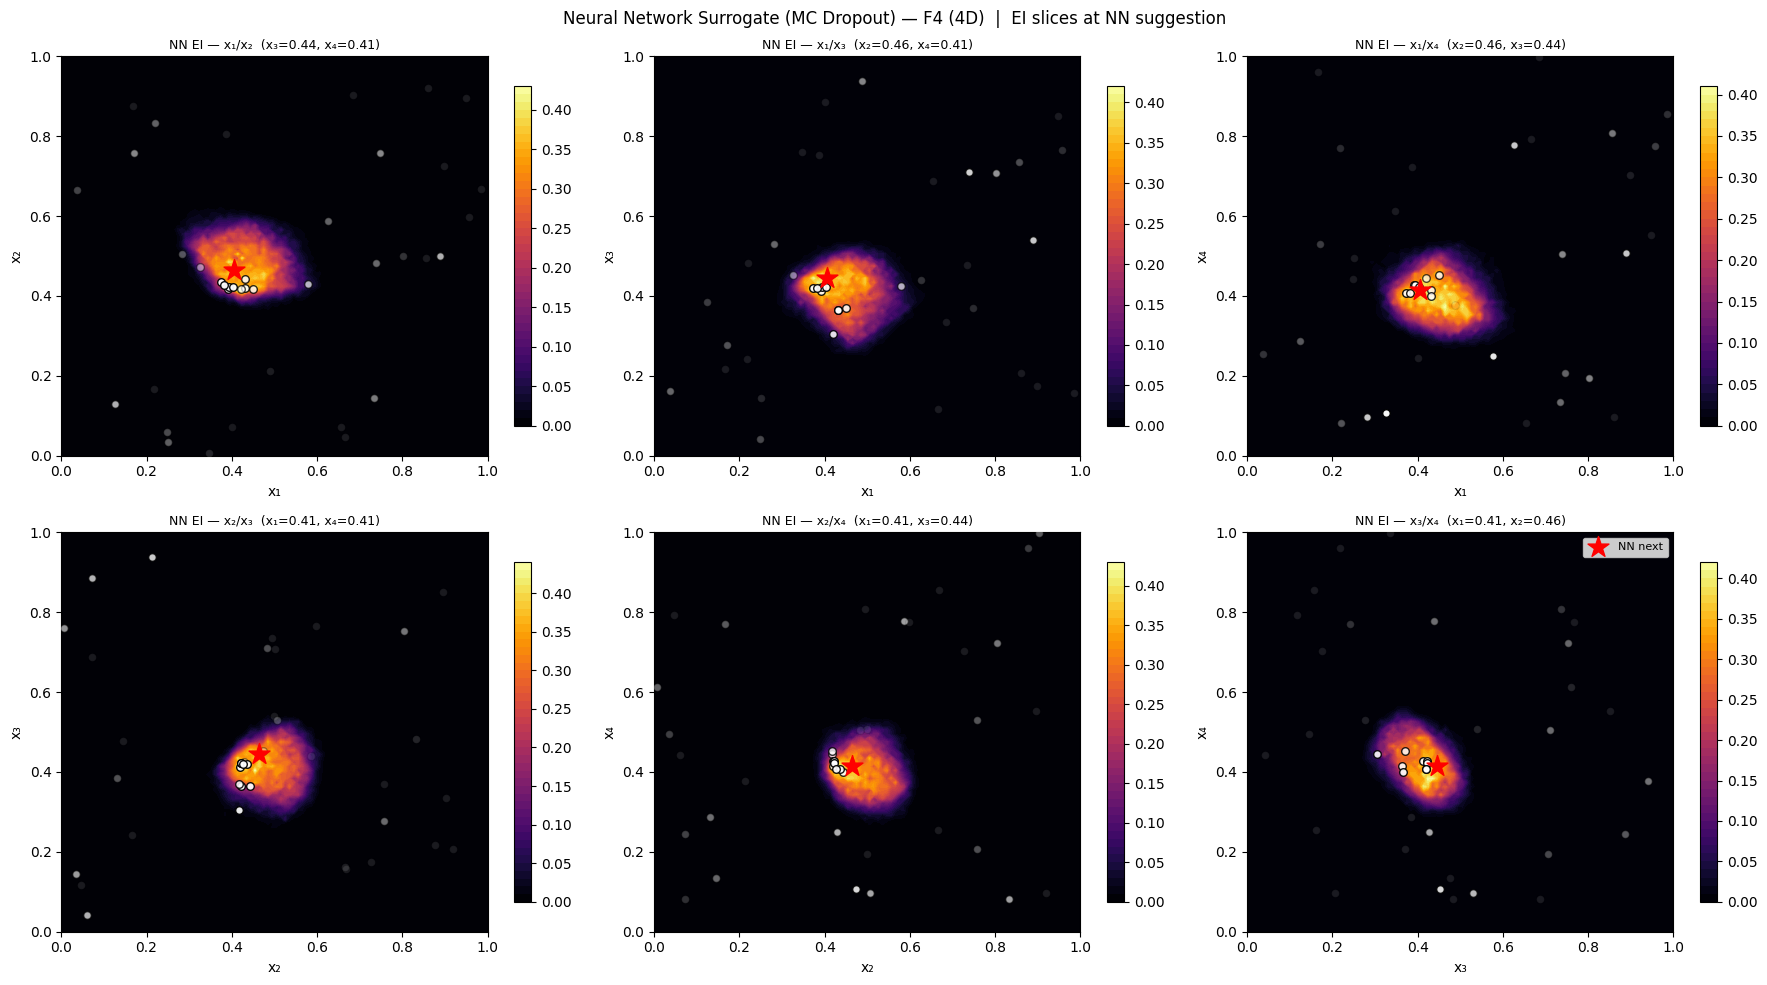

In [13]:
resolution = 100   # same as GP slice plots to keep render time reasonable
grid_1d    = np.linspace(0, 1, resolution)
G1, G2     = np.meshgrid(grid_1d, grid_1d)
flat1, flat2 = G1.ravel(), G2.ravel()

dim_labels = ["x₁", "x₂", "x₃", "x₄"]
dim_pairs  = list(combinations(range(4), 2))   # all 6 pairs

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat  = axes.ravel()
fig.suptitle(
    "Neural Network Surrogate (MC Dropout) — F4 (4D)  |  EI slices at NN suggestion",
    fontsize=12
)

for ax, (d0, d1) in zip(axes_flat, dim_pairs):
    fixed_dims = [d for d in range(4) if d not in (d0, d1)]

    # Build grid: sweep d0 & d1, fix others at best_x_nn values
    X_grid        = np.tile(best_x_nn, (resolution * resolution, 1))
    X_grid[:, d0] = flat1
    X_grid[:, d1] = flat2

    ei_vals = expected_improvement_nn(
        X_grid, nn_model, scaler_nn, y_nn_mean, y_nn_std, y_obs.max(), xi=xi_nn, n_mc=200
    ).reshape(resolution, resolution)

    im = ax.contourf(G1, G2, ei_vals, levels=50, cmap="inferno")
    fig.colorbar(im, ax=ax, shrink=0.85)

    dist   = np.mean([np.abs(X_obs[:, fd] - best_x_nn[fd]) for fd in fixed_dims], axis=0)
    alphas = np.clip(1.0 - dist / 0.3, 0.1, 1.0)
    for xi_o, yi_o, a in zip(X_obs[:, d0], X_obs[:, d1], alphas):
        ax.scatter(xi_o, yi_o, c="white", edgecolors="black",
                   s=30, alpha=float(a), zorder=5)

    ax.scatter(best_x_nn[d0], best_x_nn[d1], c="red", marker="*",
               s=250, zorder=6, label="NN next")

    fix_str = ", ".join(f"{dim_labels[fd]}={best_x_nn[fd]:.2f}" for fd in fixed_dims)
    ax.set_title(f"NN EI — {dim_labels[d0]}/{dim_labels[d1]}  ({fix_str})", fontsize=9)
    ax.set_xlabel(dim_labels[d0]); ax.set_ylabel(dim_labels[d1])

axes_flat[-1].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("nn_surrogate_f4.png", dpi=150)
plt.show()

## 14. Compare all three models: GP vs SVM vs NN

We compare the **EI score** and **suggested next point** from each surrogate:

| Model | Surrogate type | Uncertainty source |
|---|---|---|
| **GP** | Matérn 5/2 kernel | Bayesian posterior (exact) |
| **SVM** | RBF classifier | P(high region) — filters candidates |
| **NN** | MC-Dropout MLP | 200 stochastic forward passes |

A bar chart visualises the EI values directly, and pairwise distances quantify agreement between the three suggestions.

Model                                                           Suggested x           EI
------------------------------------------------------------------------------------------
GP (unconstrained)                 [0.383699, 0.425326, 0.418152, 0.405938]     0.050867
SVM-constrained                     [0.383733, 0.425344, 0.41814, 0.405971]     0.052053
NN (MC Dropout)                    [0.405642, 0.463844, 0.444369, 0.414679]     0.370993

GP  ↔ SVM distance : 0.0001
GP  ↔ NN  distance : 0.0522
SVM ↔ NN  distance : 0.0522

✅ All three models agree — very high confidence in this region.


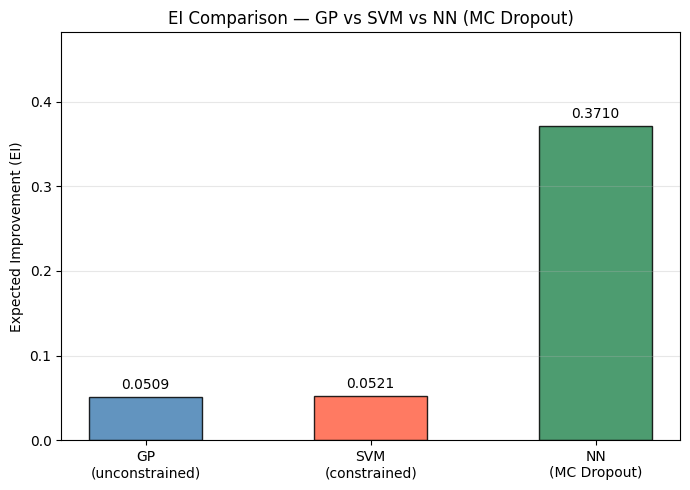

In [14]:
# ── Summary table ─────────────────────────────────────────────────────────────
print(f"{'Model':<24} {'Suggested x':>50}   {'EI':>10}")
print("-" * 90)
print(f"{'GP (unconstrained)':<24} {str(np.round(x_next, 6).tolist()):>50}   {score:>10.6f}")
print(f"{'SVM-constrained':<24} {str(np.round(best_x_svm, 6).tolist()):>50}   {best_score_svm:>10.6f}")
print(f"{'NN (MC Dropout)':<24} {str(np.round(best_x_nn, 6).tolist()):>50}   {best_score_nn:>10.6f}")

# ── Pairwise distances ────────────────────────────────────────────────────────
dist_gp_svm = np.linalg.norm(x_next - best_x_svm)
dist_gp_nn  = np.linalg.norm(x_next - best_x_nn)
dist_svm_nn = np.linalg.norm(best_x_svm - best_x_nn)

print(f"\nGP  ↔ SVM distance : {dist_gp_svm:.4f}")
print(f"GP  ↔ NN  distance : {dist_gp_nn:.4f}")
print(f"SVM ↔ NN  distance : {dist_svm_nn:.4f}")

# ── Consensus check ───────────────────────────────────────────────────────────
suggestions = [x_next, best_x_svm, best_x_nn]
centroid    = np.mean(suggestions, axis=0)
max_dev     = max(np.linalg.norm(s - centroid) for s in suggestions)

if max_dev < 0.05:
    print("\n✅ All three models agree — very high confidence in this region.")
elif max_dev < 0.15:
    print("\n⚠️  Mild disagreement — GP posterior is most principled; prefer GP suggestion.")
else:
    print("\n❗ Strong disagreement — models see different promising regions; trust the GP.")

# ── Bar chart: EI scores across the three surrogates ─────────────────────────
labels_bar    = ["GP\n(unconstrained)", "SVM\n(constrained)", "NN\n(MC Dropout)"]
ei_scores_bar = [score, best_score_svm, best_score_nn]
colors_bar    = ["steelblue", "tomato", "seagreen"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels_bar, ei_scores_bar, color=colors_bar,
              edgecolor="black", alpha=0.85, width=0.5)
ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=10)
ax.set_ylabel("Expected Improvement (EI)")
ax.set_title("EI Comparison — GP vs SVM vs NN (MC Dropout)")
ax.set_ylim(0, max(ei_scores_bar) * 1.3)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("ei_comparison_three_models_f4.png", dpi=150)
plt.show()

## 15. Hyperparameter Sensitivity — ξ (xi) Exploration (Module 18)

Module 18 identifies **ξ (xi)** as the key hyperparameter of the EI acquisition function controlling the exploration–exploitation trade-off. Rather than relying solely on the adaptive decay schedule, this section applies a **coarse grid search** over ξ — the simplest tuning strategy from Mini-lesson 18.5.

By scanning ξ ∈ {0.001 … 0.5} with the GP already fitted on all 4D observations, we can:
- Confirm the adaptive ξ is in a sensible range for the current dataset
- See how sensitive the suggested query is to this hyperparameter
- Decide whether to override the schedule if the function appears nearly converged (small ξ) or still widely uncertain (large ξ)

In [15]:
# ── ξ (xi) grid search — treating xi as a hyperparameter to tune ──────────────────
print('GP suggestion sensitivity to xi (exploration-exploitation hyperparameter):')
print(f"{'xi':>8}  {'EI score':>12}  Suggested x (CAPSTONE format)")
print('-' * 85)

xi_grid    = [0.001, 0.01, 0.05, 0.1, 0.5]
xi_current = adaptive_xi(N_ITER, xi_init=XI_INIT, decay=XI_DECAY)

for xi_test in xi_grid:
    sampler_s  = qmc.Sobol(d=n_dim, scramble=True, seed=SEED + 888)
    X_c_s      = sampler_s.random(8_192)          # 2^13 quick scan
    scores_s   = expected_improvement(X_c_s, gp, y_obs.max(), xi=xi_test)
    starts_s   = X_c_s[np.argsort(scores_s)[-5:]]
    obj_s      = lambda x, xi=xi_test: -expected_improvement(x, gp, y_obs.max(), xi=xi).item()
    bx_s, bs_s = None, -np.inf
    for x0 in starts_s:
        r = minimize(obj_s, x0=x0, bounds=[(0, 1)] * n_dim, method='L-BFGS-B')
        if -r.fun > bs_s: bs_s = -r.fun; bx_s = r.x
    capstone_s = '-'.join(f'{v:.6f}' for v in bx_s)
    marker     = '  <- adaptive (current)' if abs(xi_test - xi_current) < 0.02 else ''
    print(f'  {xi_test:>6.3f}  {bs_s:>12.6f}  {capstone_s}{marker}')

print(f'\nAdaptive xi at iteration {N_ITER}: {xi_current:.5f}  '
      f'(xi_init={XI_INIT}, decay={XI_DECAY}^{N_ITER})')

GP suggestion sensitivity to xi (exploration-exploitation hyperparameter):
      xi      EI score  Suggested x (CAPSTONE format)
-------------------------------------------------------------------------------------
   0.001      0.058772  0.383914-0.425438-0.418080-0.406151  <- adaptive (current)
   0.010      0.055463  0.383828-0.425394-0.418110-0.406066  <- adaptive (current)
   0.050      0.042360  0.383422-0.425159-0.418239-0.405661
   0.100      0.029398  0.382864-0.424728-0.418397-0.405082
   0.500      0.000651  0.384670-0.378759-0.421158-0.395472

Adaptive xi at iteration 10: 0.01969  (xi_init=0.1, decay=0.85^10)


## 16. GP Kernel Diagnostics (Module 18)

The GP kernel hyperparameters are fitted by maximising the log-marginal-likelihood. Inspecting them connects to Module 18's insight that **length scales act as feature importance scores**:

- **Small length scale** → function changes quickly along that axis → high sensitivity → important dimension
- **Large length scale** → function is nearly flat along that axis → low sensitivity → potentially irrelevant

This mirrors Module 18's note that random search works well when only a few hyperparameters heavily influence performance — the same may be true of our 4D function's input dimensions. A large length-scale disparity is a signal to focus future queries on the most sensitive dimensions.

Fitted GP kernel hyperparameters (F4, 4D):
  Amplitude  s2   : 5.9944
  Noise level     : 4.51e-04

Per-dimension length scales:
  x1:    1.5136  XXXXXXXXXXXX
  x2:    1.4446  XXXXXXXXXXXX
  x3:    1.4168  XXXXXXXXXXXX
  x4:    1.3688  XXXXXXXXXXXX

Most  sensitive dim : x4 (ls=1.3688)
Least sensitive dim : x1 (ls=1.5136)

[OK] Length scale ratio 1.1x -- all dimensions contribute similarly.


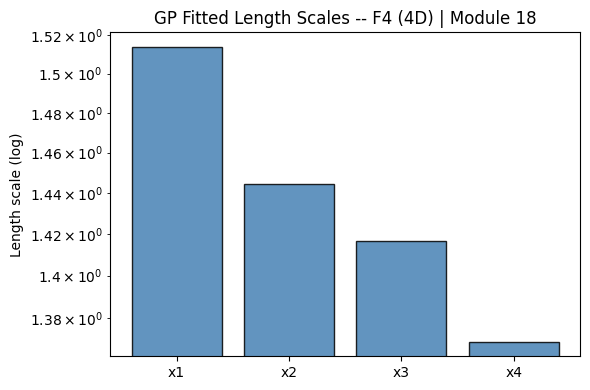

In [16]:
# ── GP fitted kernel hyperparameters ─────────────────────────────────────────────
fitted_ls = gp.kernel_.k1.k2.length_scale
noise_lv  = gp.kernel_.k2.noise_level
amplitude = gp.kernel_.k1.k1.constant_value
ls_arr    = np.array(fitted_ls)
dim_lbls  = [f'x{i+1}' for i in range(n_dim)]

print(f'Fitted GP kernel hyperparameters (F4, {n_dim}D):')
print(f'  Amplitude  s2   : {amplitude:.4f}')
print(f'  Noise level     : {noise_lv:.2e}')
print('\nPer-dimension length scales:')
for lbl, ls in zip(dim_lbls, ls_arr):
    bar = 'X' * max(1, min(int(np.log10(ls + 1e-8) * 5 + 12), 35))
    print(f'  {lbl}: {ls:9.4f}  {bar}')

if n_dim >= 3:
    idx_min, idx_max = ls_arr.argmin(), ls_arr.argmax()
    ratio = ls_arr[idx_max] / (ls_arr[idx_min] + 1e-8)
    print(f'\nMost  sensitive dim : {dim_lbls[idx_min]} (ls={ls_arr[idx_min]:.4f})')
    print(f'Least sensitive dim : {dim_lbls[idx_max]} (ls={ls_arr[idx_max]:.4f})')
    if ratio > 10:
        print(f'\n[!] Length scale ratio {ratio:.0f}x -- function may be effectively '
              f'lower-dimensional. Focus future queries around {dim_lbls[idx_min]}.')
    else:
        print(f'\n[OK] Length scale ratio {ratio:.1f}x -- all dimensions contribute similarly.')

fig, ax = plt.subplots(figsize=(max(6, n_dim * 1.3), 4))
ax.bar(dim_lbls, ls_arr, color='steelblue', edgecolor='black', alpha=0.85)
ax.set_yscale('log')
ax.set_ylabel('Length scale (log)')
ax.set_title(f'GP Fitted Length Scales -- F4 ({n_dim}D) | Module 18')
ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('length_scales_module18_f4.png', dpi=150)
plt.show()

## 17. Convergence Plot

After running multiple iterations with real evaluations, this cell plots the **best observed value over time** — the primary diagnostic for whether the optimizer is making progress. A well-functioning BO loop should show a monotonically non-decreasing curve that flattens as it approaches the true optimum.

Given the high initial EI score for F4, you may see larger jumps early on compared to F2/F3 — this is expected as the optimizer exploits the many unexplored regions of the 4D space.

Uncomment and run after completing multiple BO iterations.

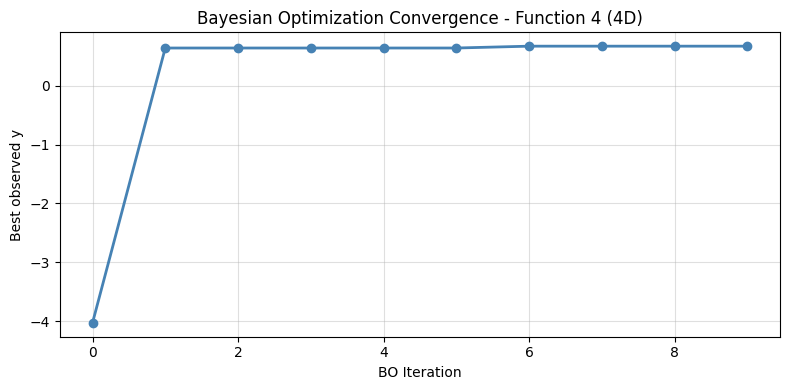

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(range(len(history_best)), history_best, marker="o", linewidth=2, color="steelblue")
plt.xlabel("BO Iteration")
plt.ylabel("Best observed y")
plt.title("Bayesian Optimization Convergence - Function 4 (4D)")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("convergence_f4.png", dpi=150)
plt.show()